### Ferritin Prediction

### Dataset Examination (Veri Setinin İncelenmesi)

In [ ]:
#Kutuphanelerin Dahil Edilmesi
import numpy as np
import pandas as pd
import random

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
%matplotlib inline

from joblib import dump, load

from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.model_selection import train_test_split, GridSearchCV, validation_curve
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import auc, roc_curve, precision_recall_curve, average_precision_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.impute import KNNImputer

import warnings
warnings.filterwarnings("ignore")

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.5f' % x)

In [ ]:
#Veri Setinin Okunmasi
df = pd.read_excel("ferritin_data.xlsx")
df.drop('No', axis=1, inplace=True)
#df.drop('Ferritin Level', axis=1, inplace=True)
data = df.copy()

In [ ]:
# Veri Setine Genel Bakis icin Fonksiyonlar
def check_df(dataframe, head=5):
    print("##################### Shape #####################")
    print(dataframe.shape)
    print("##################### Types #####################")
    print(dataframe.dtypes)
    print("##################### Head #####################")
    print(dataframe.head(head))
    print("##################### Tail #####################")
    print(dataframe.tail(head))
    print("##################### NA #####################")
    print(dataframe.isnull().sum())
    print("##################### Quantiles #####################")
    print(dataframe.quantile([0, 0.05, 0.50, 0.95, 0.99, 1]).T)

def cat_summary(dataframe, col_name, plot=False):
    print(pd.DataFrame({col_name: dataframe[col_name].value_counts(),
                        "Ratio": 100 * dataframe[col_name].value_counts() / len(dataframe)}))
    print("##########################################")
    if plot:
        sns.countplot(x=dataframe[col_name], data=dataframe)
        plt.show(block=True)

def num_summary(dataframe, numerical_col, plot=False):
    quantiles = [0.05, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 0.95, 0.99]
    print(dataframe[numerical_col].describe(quantiles).T)

    if plot:
        dataframe[numerical_col].hist(bins=20)
        plt.xlabel(numerical_col)
        plt.title(numerical_col)
        plt.show(block=True)

def target_summary_with_num(dataframe, target, numerical_col):
    print(dataframe.groupby(target).agg({numerical_col: "mean"}), end="\n\n\n")

def target_summary_with_cat(dataframe, target, categorical_col):
    print(pd.DataFrame({"TARGET_MEAN": dataframe.groupby(categorical_col)[target].mean()}), end="\n\n\n")

def plot_target_summary_with_cat(dataframe, target, categorical_col):
    mean_values = dataframe.groupby(categorical_col)[target].mean().reset_index()
    fig = px.bar(mean_values, x=categorical_col, y=target, title=f'{categorical_col} - {target} (Mean)',
                 color=categorical_col, color_discrete_sequence=px.colors.qualitative.Set2)
    fig.update_layout(bargap=0.2)
    fig.show()

def correlation_matrix(df, cols):
    fig = plt.gcf()
    fig.set_size_inches(10, 8)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    fig = sns.heatmap(df[cols].corr(), annot=True, linewidths=0.5, annot_kws={'size': 12}, linecolor='w', cmap='RdBu')
    plt.show(block=True)

def grab_col_names(dataframe, cat_th=15, car_th=20):
    """

    Veri setindeki kategorik, numerik ve kategorik fakat kardinal değişkenlerin isimlerini verir.
    Not: Kategorik değişkenlerin içerisine numerik görünümlü kategorik değişkenler de dahildir.

    Parameters
    ------
        dataframe: dataframe
                Değişken isimleri alınmak istenilen dataframe
        cat_th: int, optional
                numerik fakat kategorik olan değişkenler için sınıf eşik değeri
        car_th: int, optinal
                kategorik fakat kardinal değişkenler için sınıf eşik değeri

    Returns
    ------
        cat_cols: list
                Kategorik değişken listesi
        num_cols: list
                Numerik değişken listesi
        cat_but_car: list
                Kategorik görünümlü kardinal değişken listesi

    Examples
    ------
        import seaborn as sns
        df = sns.load_dataset("iris")
        print(grab_col_names(df))


    Notes
    ------
        cat_cols + num_cols + cat_but_car = toplam değişken sayısı
        num_but_cat cat_cols'un içerisinde.
        Return olan 3 liste toplamı toplam değişken sayısına eşittir: cat_cols + num_cols + cat_but_car = değişken sayısı

    """

    # cat_cols, cat_but_car
    cat_cols = [col for col in dataframe.columns if dataframe[col].dtypes == "O"]
    num_but_cat = [col for col in dataframe.columns if dataframe[col].nunique() < cat_th and
                   dataframe[col].dtypes != "O"]
    cat_but_car = [col for col in dataframe.columns if dataframe[col].nunique() > car_th and
                   dataframe[col].dtypes == "O"]
    cat_cols = cat_cols + num_but_cat
    cat_cols = [col for col in cat_cols if col not in cat_but_car]

    # num_cols
    num_cols = [col for col in dataframe.columns if dataframe[col].dtypes != "O"]
    num_cols = [col for col in num_cols if col not in num_but_cat]

    # print(f"Observations: {dataframe.shape[0]}")
    # print(f"Variables: {dataframe.shape[1]}")
    # print(f'cat_cols: {len(cat_cols)}')
    # print(f'num_cols: {len(num_cols)}')
    # print(f'cat_but_car: {len(cat_but_car)}')
    # print(f'num_but_cat: {len(num_but_cat)}')
    return cat_cols, num_cols, cat_but_car

In [ ]:
#Veri Setindeki ilk 10 veriye goz atma
df.head(n=10)

,Yaş,Cinsiyet,HGB (12-16),MCV (81-101),HCT (36-44),WBC (4.5-10),MPV (9-12),MCH (27-35),RDW-CV (11.5-14.5),Ferritin (30-400),Ferritin Level
0,50,Kadın,6.50000,61.10000,26.10000,5.36000,10.20000,15.20000,19.30000,2.20000,1
1,21,Kadın,9.10000,71.90000,31.70000,3.79000,11.60000,20.60000,16.20000,2.30000,1
2,27,Kadın,7.90000,63.10000,29.40000,5.24000,10.10000,17.00000,20.70000,2.40000,1
3,23,Kadın,6.70000,59.90000,24.30000,3.12000,9.10000,16.50000,20.90000,2.40000,1
4,49,Kadın,6.90000,64.00000,25.20000,7.55000,10.70000,17.50000,18.80000,2.60000,1
5,47,Kadın,7.20000,61.60000,25.70000,6.60000,10.70000,17.30000,18.70000,2.70000,1
6,47,Kadın,6.50000,66.10000,24.80000,5.45000,9.90000,17.30000,23.60000,2.80000,1
7,31,Kadın,8.50000,64.30000,30.50000,7.27000,9.70000,17.90000,19.10000,2.90000,1
8,29,Kadın,8.20000,65.30000,31.40000,7.87000,9.60000,17.00000,20.30000,3.00000,1
9,44,Kadın,5.80000,59.70000,22.40000,6.67000,9.80000,15.50000,21.20000,3.00000,1


In [ ]:
#Veri Setindeki son 10 veriye goz atma
df.tail(n=10)

,Yaş,Cinsiyet,HGB (12-16),MCV (81-101),HCT (36-44),WBC (4.5-10),MPV (9-12),MCH (27-35),RDW-CV (11.5-14.5),Ferritin (30-400),Ferritin Level
7190,81,Kadın,12.00000,95.00000,38.30000,9.17000,11.80000,29.80000,13.40000,391.00000,0
7191,53,Erkek,14.60000,89.20000,44.40000,8.87000,9.00000,29.30000,12.00000,394.00000,0
7192,55,Erkek,14.90000,94.20000,45.80000,6.03000,12.20000,30.70000,13.90000,395.00000,0
7193,45,Erkek,15.30000,91.20000,44.70000,7.71000,10.60000,31.20000,11.80000,395.00000,0
7194,54,Erkek,15.00000,89.20000,44.00000,9.23000,10.00000,30.40000,12.40000,396.00000,0
7195,67,Kadın,14.90000,87.60000,44.70000,8.60000,10.90000,29.20000,11.70000,397.00000,0
7196,60,Erkek,16.90000,89.90000,49.90000,7.61000,10.50000,30.50000,13.20000,398.00000,0
7197,74,Erkek,13.50000,93.40000,40.80000,7.41000,10.50000,30.90000,13.20000,398.00000,0
7198,72,Erkek,12.10000,96.10000,37.30000,7.14000,9.50000,31.20000,12.90000,399.00000,0
7199,28,Erkek,16.30000,82.10000,48.60000,6.64000,10.40000,27.50000,12.30000,399.00000,0


In [ ]:
#Veri setinin satir, sutun sayısı
print("################ Shape ################ ")
print(df.shape)
print("Gozlem (n) sayisi:", len(df.index))
print("Degisken (variable) sayisi:",len(df.columns))

################ Shape ################ 
(7200, 11)
Gozlem (n) sayisi: 7200
Degisken (variable) sayisi: 11


In [ ]:
#Verilen Tipleri (Data Types)
print("################ Data Types ################")
df['Yaş'] = df['Yaş'].astype('float64')
df.dtypes

################ Data Types ################


Yaş                   float64
Cinsiyet               object
HGB (12-16)           float64
MCV (81-101)          float64
HCT (36-44)           float64
WBC (4.5-10)          float64
MPV (9-12)            float64
MCH (27-35)           float64
RDW-CV (11.5-14.5)    float64
Ferritin (30-400)     float64
Ferritin Level          int64
dtype: object

In [ ]:
# Eksik verilere (Missing Value) bakma
print("################ Missing Values ################")
df.isnull().sum()

################ Missing Values ################


Yaş                   0
Cinsiyet              0
HGB (12-16)           0
MCV (81-101)          0
HCT (36-44)           0
WBC (4.5-10)          0
MPV (9-12)            0
MCH (27-35)           0
RDW-CV (11.5-14.5)    0
Ferritin (30-400)     0
Ferritin Level        0
dtype: int64

In [ ]:
#Kategorik ve Numerik Degiskenleri Yakalama
cat_cols, num_cols, cat_but_car = grab_col_names(df)

In [ ]:
# Toplam Degisken Sayisi
print("Toplam degisken sayisi:", len(cat_cols+num_cols+cat_but_car))

# kac adet kategorik degisken var
print("Kategorik degisken sayisi:", len(cat_cols))

# kac adet numerik degisken var
print("Numerik degisken sayisi:", len(num_cols))

# kac adet kategorik olan ama kardinal degisken var
print("Kategorik ama kardinal gorunen degisken sayisi:", len(cat_but_car))

Toplam degisken sayisi: 11
Kategorik degisken sayisi: 2
Numerik degisken sayisi: 9
Kategorik ama kardinal gorunen degisken sayisi: 0


In [ ]:
#Kategorik degiskenlerin icindeki tekil (unique) verileri bulma
for col in df.columns:
    values = []

    # numerik olmayanlar -> kategorik
    if col == 'Cinsiyet' or col == 'Ferritin Level':
        for val in df[col].unique():
            values.append(val)

        print("{0} -> {1}".format(col, values))

Cinsiyet -> ['Kadın', 'Erkek']
Ferritin Level -> [1, 0]


In [ ]:
# Numerik degiskenlerin icindeki tekil (unique) verileri bulma
for col in df.columns:
    values = []

    # kategorik olmayanlar -> numerik
    if col in df.describe().columns and col != 'Ferritin Level':
        for val in df[col].unique():
            values.append(val)

        print("{0} -> {1} ...".format(col, values[:5]))

Yaş -> [50.0, 21.0, 27.0, 23.0, 49.0] ...
HGB (12-16) -> [6.5, 9.1, 7.9, 6.7, 6.9] ...
MCV (81-101) -> [61.1, 71.9, 63.1, 59.9, 64.0] ...
HCT (36-44) -> [26.1, 31.7, 29.4, 24.3, 25.2] ...
WBC (4.5-10) -> [5.36, 3.79, 5.24, 3.12, 7.55] ...
MPV (9-12) -> [10.2, 11.6, 10.1, 9.1, 10.7] ...
MCH (27-35) -> [15.2, 20.6, 17.0, 16.5, 17.5] ...
RDW-CV (11.5-14.5) -> [19.3, 16.2, 20.7, 20.9, 18.8] ...
Ferritin (30-400) -> [2.2, 2.3, 2.4, 2.6, 2.7] ...


In [ ]:
# her sutun icindeki tekil (unique) veri adedine bakma
for col in df.columns:
    print(col, df[col].nunique())

Yaş 80
Cinsiyet 2
HGB (12-16) 136
MCV (81-101) 406
HCT (36-44) 313
WBC (4.5-10) 676
MPV (9-12) 67
MCH (27-35) 198
RDW-CV (11.5-14.5) 135
Ferritin (30-400) 1156
Ferritin Level 2


In [ ]:
#Genel Bilgiler
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7200 entries, 0 to 7199
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Yaş                 7200 non-null   float64
 1   Cinsiyet            7200 non-null   object 
 2   HGB (12-16)         7200 non-null   float64
 3   MCV (81-101)        7200 non-null   float64
 4   HCT (36-44)         7200 non-null   float64
 5   WBC (4.5-10)        7200 non-null   float64
 6   MPV (9-12)          7200 non-null   float64
 7   MCH (27-35)         7200 non-null   float64
 8   RDW-CV (11.5-14.5)  7200 non-null   float64
 9   Ferritin (30-400)   7200 non-null   float64
 10  Ferritin Level      7200 non-null   int64  
dtypes: float64(9), int64(1), object(1)
memory usage: 618.9+ KB


In [ ]:
# Numerik degiskenlerin incelenmesi
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Yaş,7200.00000,46.74222,18.16979,18.00000,31.00000,46.00000,61.00000,102.00000
HGB (12-16),7200.00000,13.49181,1.84875,4.50000,12.40000,13.50000,14.60000,19.50000
MCV (81-101),7200.00000,87.90182,6.04394,58.10000,84.90000,88.60000,91.60000,125.30000
HCT (36-44),7200.00000,41.58249,4.80125,17.00000,38.80000,41.60000,44.60000,57.90000
WBC (4.5-10),7200.00000,7.03748,1.47657,1.30000,5.97000,7.02000,8.12000,9.99000
MPV (9-12),7200.00000,10.57585,0.92413,7.90000,9.90000,10.50000,11.20000,14.80000
MCH (27-35),7200.00000,28.49978,2.66938,15.20000,27.30000,29.00000,30.20000,46.30000
RDW-CV (11.5-14.5),7200.00000,13.75500,1.77256,10.40000,12.60000,13.20000,14.30000,26.50000
Ferritin (30-400),7200.00000,56.02671,62.74846,2.20000,16.30000,29.95000,72.00000,399.00000


In [ ]:
# Numerik degiskenlerin incelenmesi - Aykiri Deger Tespiti icin On Bakis
df[num_cols].quantile([0, 0.05, 0.50, 0.95, 0.99, 1]).T

,0.00000,0.05000,0.50000,0.95000,0.99000,1.00000
Yaş,18.00000,20.95000,46.00000,78.00000,86.00000,102.00000
HGB (12-16),4.50000,10.40000,13.50000,16.50000,17.60000,19.50000
MCV (81-101),58.10000,77.00000,88.60000,96.20000,100.50000,125.30000
HCT (36-44),17.00000,33.80000,41.60000,49.40000,52.10100,57.90000
WBC (4.5-10),1.30000,4.61000,7.02000,9.46050,9.87000,9.99000
MPV (9-12),7.90000,9.20000,10.50000,12.20000,13.00000,14.80000
MCH (27-35),15.20000,23.30000,29.00000,31.90000,33.30000,46.30000
RDW-CV (11.5-14.5),10.40000,12.00000,13.20000,17.20000,20.50000,26.50000
Ferritin (30-400),2.20000,7.40000,29.95000,192.05000,306.07000,399.00000


In [ ]:
# Kategorik degiskenlerin incelenmesi
for col in cat_cols:
  cat_summary(df, col)

          Cinsiyet    Ratio
Cinsiyet                   
Kadın         5240 72.77778
Erkek         1960 27.22222
##########################################
                Ferritin Level    Ratio
Ferritin Level                         
1                         3600 50.00000
0                         3600 50.00000
##########################################


In [ ]:
#Kategorik ve Numerik Degiskenleri Yeniden Yakalama
cat_cols, num_cols, cat_but_car = grab_col_names(df)

In [ ]:
#Veri setindeki 5 ilk bes veriye goz atma
df.head(n=5)

,Yaş,Cinsiyet,HGB (12-16),MCV (81-101),HCT (36-44),WBC (4.5-10),MPV (9-12),MCH (27-35),RDW-CV (11.5-14.5),Ferritin (30-400),Ferritin Level
0,50.00000,Kadın,6.50000,61.10000,26.10000,5.36000,10.20000,15.20000,19.30000,2.20000,1
1,21.00000,Kadın,9.10000,71.90000,31.70000,3.79000,11.60000,20.60000,16.20000,2.30000,1
2,27.00000,Kadın,7.90000,63.10000,29.40000,5.24000,10.10000,17.00000,20.70000,2.40000,1
3,23.00000,Kadın,6.70000,59.90000,24.30000,3.12000,9.10000,16.50000,20.90000,2.40000,1
4,49.00000,Kadın,6.90000,64.00000,25.20000,7.55000,10.70000,17.50000,18.80000,2.60000,1


Dolayısı ile veriseti icinde:

 - Toplam **7200 gozlem birimi** var.
 - Toplam **11 degisken** var:
  - **9 degisken** numerik
  - **2 degisken** kategorik
  - ##############################
  - **9 bagimsiz degisken:** 'Yaş', 'Cinsiyet', 'HGB (12-16)', 'MCV (81-101)', 'HCT (36-44)'', 'WBC (4.5-10)', 'MPV (9-12)', 'MCH (27-35)', 'RDW-CV (11.5-14.5)'
  - **2 bagimli degisken:** 'Ferritin (30-400)', 'Ferritin Level'

### Data Preprocessing (Veri Ön İşleme)

#### Outlier Analysis/Detection (Aykiri Deger Analizi)

In [ ]:
def outlier_thresholds(dataframe, col_name, q1=0.05, q3=0.95):
    quartile1 = dataframe[col_name].quantile(q1)
    quartile3 = dataframe[col_name].quantile(q3)
    interquantile_range = quartile3 - quartile1
    up_limit = quartile3 + 1.5 * interquantile_range
    low_limit = quartile1 - 1.5 * interquantile_range
    return low_limit, up_limit

def replace_with_thresholds(dataframe, variable):
    low_limit, up_limit = outlier_thresholds(dataframe, variable)
    dataframe.loc[(dataframe[variable] < low_limit), variable] = low_limit
    dataframe.loc[(dataframe[variable] > up_limit), variable] = up_limit

def check_outlier(dataframe, col_name, q1=0.05, q3=0.95):
    low_limit, up_limit = outlier_thresholds(dataframe, col_name, q1, q3)
    if dataframe[(dataframe[col_name] > up_limit) | (dataframe[col_name] < low_limit)].any(axis=None):
        return True
    else:
        return False

def grab_outliers(dataframe, col_name, index=False):
    low, up = outlier_thresholds(dataframe, col_name)

    if dataframe[((dataframe[col_name] < low) | (dataframe[col_name] > up))].shape[0] > 10:
        print(dataframe[((dataframe[col_name] < low) | (dataframe[col_name] > up))].head())
    else:
        print(dataframe[((dataframe[col_name] < low) | (dataframe[col_name] > up))])

    if index:
        outlier_index = dataframe[((dataframe[col_name] < low) | (dataframe[col_name] > up))].index
        return outlier_index

def remove_outlier(dataframe, col_name):
    low_limit, up_limit = outlier_thresholds(dataframe, col_name)
    df_without_outliers = dataframe[~((dataframe[col_name] < low_limit) | (dataframe[col_name] > up_limit))]
    return df_without_outliers

In [ ]:
#Aykiri Deger Analizi -> Verilen araliklar disinda kalanaykiri degerler yok
for col in ['Yaş','HGB (12-16)','MCV (81-101)','HCT (36-44)','WBC (4.5-10)','MPV (9-12)','MCH (27-35)','RDW-CV (11.5-14.5)']:
    print(col,':', check_outlier(df, col, 0.05, 0.95))

Yaş : False
HGB (12-16) : False
MCV (81-101) : True
HCT (36-44) : False
WBC (4.5-10) : False
MPV (9-12) : False
MCH (27-35) : True
RDW-CV (11.5-14.5) : True


In [ ]:
# Baskılama Yöntemi (re-assignment with thresholds) ile 'MCV (81-101)','MCH (27-35)', 'RDW-CV (11.5-14.5)' degiskenleri baskilandi.
for col in ['MCV (81-101)','MCH (27-35)','RDW-CV (11.5-14.5)']:
    replace_with_thresholds(df, col)

In [ ]:
#Aykiri Deger Analizi -> Verilen araliklar disinda kalan aykiri degerler yok
for col in ['Yaş','HGB (12-16)','MCV (81-101)','HCT (36-44)','WBC (4.5-10)','MPV (9-12)','MCH (27-35)','RDW-CV (11.5-14.5)']:
    print(col,':', check_outlier(df, col, 0.05, 0.95))

Yaş : False
HGB (12-16) : False
MCV (81-101) : False
HCT (36-44) : False
WBC (4.5-10) : False
MPV (9-12) : False
MCH (27-35) : False
RDW-CV (11.5-14.5) : False


#### Detection and Imputation of Missing Values (Kayıp/Eksik Verilerin Tespiti ve Giderilmesi)

In [ ]:
def missing_values_table(dataframe, na_name=False):
    na_columns = [col for col in dataframe.columns if dataframe[col].isnull().sum() > 0]

    n_miss = dataframe[na_columns].isnull().sum().sort_values(ascending=False)
    ratio = (dataframe[na_columns].isnull().sum() / dataframe.shape[0] * 100).sort_values(ascending=False)
    missing_df = pd.concat([n_miss, np.round(ratio, 2)], axis=1, keys=['n_miss', 'ratio'])
    print(missing_df, end="\n")

    if na_name:
        return na_columns

missing_values_table(df) # Veri setinde eksik değer yok.

Empty DataFrame
Columns: [n_miss, ratio]
Index: []


In [ ]:
#Kategorik ve Numerik Degiskenleri Yeniden Yakalama
cat_cols, num_cols, cat_but_car = grab_col_names(df)

df.head(n=5)

,Yaş,Cinsiyet,HGB (12-16),MCV (81-101),HCT (36-44),WBC (4.5-10),MPV (9-12),MCH (27-35),RDW-CV (11.5-14.5),Ferritin (30-400),Ferritin Level
0,50.00000,Kadın,6.50000,61.10000,26.10000,5.36000,10.20000,15.20000,19.30000,2.20000,1
1,21.00000,Kadın,9.10000,71.90000,31.70000,3.79000,11.60000,20.60000,16.20000,2.30000,1
2,27.00000,Kadın,7.90000,63.10000,29.40000,5.24000,10.10000,17.00000,20.70000,2.40000,1
3,23.00000,Kadın,6.70000,59.90000,24.30000,3.12000,9.10000,16.50000,20.90000,2.40000,1
4,49.00000,Kadın,6.90000,64.00000,25.20000,7.55000,10.70000,17.50000,18.80000,2.60000,1


In [ ]:
#Kategorik ve numerik degiskenleri yeniden yakalama
cat_cols, num_cols, cat_but_car = grab_col_names(df)
print('Kategorik Degiskenler:',cat_cols)
print('Numerik Degiskenler:',num_cols)
df.info()

Kategorik Degiskenler: ['Cinsiyet', 'Ferritin Level']
Numerik Degiskenler: ['Yaş', 'HGB (12-16)', 'MCV (81-101)', 'HCT (36-44)', 'WBC (4.5-10)', 'MPV (9-12)', 'MCH (27-35)', 'RDW-CV (11.5-14.5)', 'Ferritin (30-400)']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7200 entries, 0 to 7199
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Yaş                 7200 non-null   float64
 1   Cinsiyet            7200 non-null   object 
 2   HGB (12-16)         7200 non-null   float64
 3   MCV (81-101)        7200 non-null   float64
 4   HCT (36-44)         7200 non-null   float64
 5   WBC (4.5-10)        7200 non-null   float64
 6   MPV (9-12)          7200 non-null   float64
 7   MCH (27-35)         7200 non-null   float64
 8   RDW-CV (11.5-14.5)  7200 non-null   float64
 9   Ferritin (30-400)   7200 non-null   float64
 10  Ferritin Level      7200 non-null   int64  
dtypes: float64(9), int64(1), object(1)

#### Feature Engineering (Ozellik Muhendisligi) -> Optional

In [ ]:
# # Yeni Degiskenlerin Olusturulmasi
#
# # MPV
# df['New_MPV (9-12)'] = pd.cut(x=df['MPV (9-12)'], bins=[9, 10.5, 11.001, 12.5], labels=["Low", "Mid","High"])
#
# # MCH
# df['New_MCH (27-35'] = pd.cut(x=df['MCH (27-35)'], bins=[27, 30, 35.001, 36], labels =["Low", "Mid","High"])
#
# #Kategorik ve Numerik Degiskenleri Yeniden Yakalama
# cat_cols, num_cols, cat_but_car = grab_col_names(df)
#
# #Kategorik ve Numerik Degiskenlerin Ekrana Yazidirilmasi
#
# print('Kategorik Degiskenler:',cat_cols)
# print('Numerik Degiskenler:',num_cols)
# df[cat_cols] = df[cat_cols].astype('object')
# df.head(n=5)

In [ ]:
# # Türetilen Kategorik Degiskenlerin Incelenmesi
# for col in ['New_MPV (9-12)','New_MCH (27-35']:
#    cat_summary(df, col)

#### Rare kategoriler ile bagimli degisken arasındaki iliskinin analiz edilmesi

In [ ]:
# Rare_analyzer fonksiyonunun ile degiskenlerin analizi
def rare_analyser(dataframe, target, cat_cols):
    for col in cat_cols:
        print(col, ":", len(dataframe[col].value_counts()))
        print(pd.DataFrame({"COUNT": dataframe[col].value_counts(),
                            "RATIO": dataframe[col].value_counts() / len(dataframe),
                            "TARGET_MEAN": dataframe.groupby(col)[target].mean()}), end="\n\n\n")

rare_analyser(df, "Ferritin (30-400)", cat_cols)

Cinsiyet : 2
          COUNT   RATIO  TARGET_MEAN
Cinsiyet                            
Erkek      1960 0.27222     96.81760
Kadın      5240 0.72778     40.76905


Ferritin Level : 2
                COUNT   RATIO  TARGET_MEAN
Ferritin Level                            
0                3600 0.50000     95.38111
1                3600 0.50000     16.67231




In [ ]:
# Rare_encoder fonksiyonunun yazilmasi
def rare_encoder(dataframe, rare_perc):
    temp_df = dataframe.copy()

    rare_columns = [col for col in temp_df.columns if temp_df[col].dtypes == 'O'
                    and (temp_df[col].value_counts() / len(temp_df) < rare_perc).any(axis=None)]

    for var in rare_columns:
        tmp = temp_df[var].value_counts() / len(temp_df)
        rare_labels = tmp[tmp < rare_perc].index
        temp_df[var] = np.where(temp_df[var].isin(rare_labels), 'Rare', temp_df[var])

    return temp_df

# Kategoriler analiz edildi, Cinsiyet ve Ferritin degiskeninde birlestirme yapilmadi..
df = rare_encoder(df, 0.01)

# Rare_analyzer fonksiyonunun ile degiskenlerin analizi
rare_analyser(df, "Ferritin (30-400)", cat_cols)

Cinsiyet : 2
          COUNT   RATIO  TARGET_MEAN
Cinsiyet                            
Erkek      1960 0.27222     96.81760
Kadın      5240 0.72778     40.76905


Ferritin Level : 2
                COUNT   RATIO  TARGET_MEAN
Ferritin Level                            
0                3600 0.50000     95.38111
1                3600 0.50000     16.67231




In [ ]:
df.head(n=5)

,Yaş,Cinsiyet,HGB (12-16),MCV (81-101),HCT (36-44),WBC (4.5-10),MPV (9-12),MCH (27-35),RDW-CV (11.5-14.5),Ferritin (30-400),Ferritin Level
0,50.00000,Kadın,6.50000,61.10000,26.10000,5.36000,10.20000,15.20000,19.30000,2.20000,1
1,21.00000,Kadın,9.10000,71.90000,31.70000,3.79000,11.60000,20.60000,16.20000,2.30000,1
2,27.00000,Kadın,7.90000,63.10000,29.40000,5.24000,10.10000,17.00000,20.70000,2.40000,1
3,23.00000,Kadın,6.70000,59.90000,24.30000,3.12000,9.10000,16.50000,20.90000,2.40000,1
4,49.00000,Kadın,6.90000,64.00000,25.20000,7.55000,10.70000,17.50000,18.80000,2.60000,1


#### One-Hot Encoding (Kategorik Verilerin Donusturulmesi)

In [ ]:
#Cinsiyet degiskeninin sayisal veriye donusturulmesi Kadin -> 0, Erkek -> 1
df["Cinsiyet"] = df["Cinsiyet"].map({"Kadın": 0, "Erkek": 1}).astype("float64")

#Sutun isimlerini degistirme
df.columns = ['Age', 'Sex', 'HGB', 'MCV', 'HCT', 'WBC', 'MPV', 'MCH', 'RDW-CV', 'Ferritin', 'Ferritin_Level']
#Kategorik ve Numerik Degiskenleri Yeniden Yakalama
cat_cols, num_cols, cat_but_car = grab_col_names(df)

print('Kategorik Degiskenler:', cat_cols)
print('#####################')
print('Numerik Degiskenler:',num_cols)

Kategorik Degiskenler: ['Sex', 'Ferritin_Level']
#####################
Numerik Degiskenler: ['Age', 'HGB', 'MCV', 'HCT', 'WBC', 'MPV', 'MCH', 'RDW-CV', 'Ferritin']


In [ ]:
df.head(n=5)

,Age,Sex,HGB,MCV,HCT,WBC,MPV,MCH,RDW-CV,Ferritin,Ferritin_Level
0,50.00000,0.00000,6.50000,61.10000,26.10000,5.36000,10.20000,15.20000,19.30000,2.20000,1
1,21.00000,0.00000,9.10000,71.90000,31.70000,3.79000,11.60000,20.60000,16.20000,2.30000,1
2,27.00000,0.00000,7.90000,63.10000,29.40000,5.24000,10.10000,17.00000,20.70000,2.40000,1
3,23.00000,0.00000,6.70000,59.90000,24.30000,3.12000,9.10000,16.50000,20.90000,2.40000,1
4,49.00000,0.00000,6.90000,64.00000,25.20000,7.55000,10.70000,17.50000,18.80000,2.60000,1


####  Feature Vector and Target Variable (Bagimsiz Degiskenler ve Bagimli Degisken)

In [ ]:
X = df.drop(['Ferritin', 'Ferritin_Level'], axis=1) # Bagimsiz Degiskenler
y = df['Ferritin_Level'] # Bagimli Degisken

(X.shape, y.shape)

((7200, 9), (7200,))

#### Train-Test Split (Egitim-Test Veri Setlerinin Ayrilmasi)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 17)

# X_train ve X_test sekilleri

X_train.shape, X_test.shape

((5040, 9), (2160, 9))

#### Feature Scaling (Oznitelik Olceklendirilmesi)

In [ ]:
#Standard Scaler kullanılmasi
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Sayisal degiskenlerin belirlenmesi (one-hot encoding sonrası kategorikler disarida birakildi
numeric_columns = ['Age', 'HGB', 'MCV', 'HCT', 'WBC', 'MPV', 'MCH', 'RDW-CV']

# Sayısal degiskenlerin secilmesi
X_train_numeric = X_train[numeric_columns]
X_test_numeric = X_test[numeric_columns]

X_train_encoded = X_train.drop(columns=numeric_columns)
X_test_encoded = X_test.drop(columns=numeric_columns)

X_train_numeric_scaled = scaler.fit_transform(X_train_numeric)
X_test_numeric_scaled = scaler.transform(X_test_numeric)

# DataFrame olarak geri donusturulmesi (İndeks ve sütun isimlerini koruyarak)
X_train_numeric_scaled = pd.DataFrame(X_train_numeric_scaled, columns=numeric_columns, index=X_train.index)
X_test_numeric_scaled = pd.DataFrame(X_test_numeric_scaled, columns=numeric_columns, index=X_test.index)

# Sayisal ve one-hot encoded verileri birlestirelim
X_train = pd.concat([X_train_numeric_scaled, X_train_encoded], axis=1)
X_test = pd.concat([X_test_numeric_scaled, X_test_encoded], axis=1)

In [ ]:
#Min Max Scaler kullanılmasi -> Alternatif olarak
#from sklearn.preprocessing import MinMaxScaler

#scaler = MinMaxScaler()

#numeric_columns = X_train.select_dtypes(include=['int64', 'float64']).columns

#X_train[numeric_columns] = scaler.fit_transform(X_train[numeric_columns])
#X_test[numeric_columns] = scaler.transform(X_test[numeric_columns])

In [ ]:
#X_train veri setinde ilk 5 veriye goz atma
X_train.head(n=5)

,Age,HGB,MCV,HCT,WBC,MPV,MCH,RDW-CV,Sex
874,-0.25889,-0.09877,-0.74955,0.09017,1.76254,0.25564,-0.77928,0.18354,0.00000
3908,-0.42470,1.02592,0.82271,1.03737,-1.42441,-1.48520,0.83713,-0.53894,1.00000
6123,0.29379,0.81169,0.26000,1.03737,-0.49656,-0.83238,0.12290,-0.81681,1.00000
6154,0.07271,0.49035,0.62411,0.83146,-0.24107,-0.72358,0.16049,-0.65009,0.00000
4685,0.79120,-0.04521,-0.03790,0.17254,-1.26977,1.23487,-0.29060,-0.20549,0.00000


In [ ]:
#X_test veri setinde ilk 5 veriye goz atma
X_test.head(n=5)

,Age,HGB,MCV,HCT,WBC,MPV,MCH,RDW-CV,Sex
3622,-0.14836,0.81169,-0.25305,0.41963,-1.43786,0.47325,0.46122,-0.76124,0.00000
5407,0.84647,-0.36655,0.64066,-0.54816,-0.07970,-0.39717,0.64918,-0.42779,0.00000
5345,1.01227,0.65102,-0.40200,0.95501,0.60610,-0.50597,-0.47856,-0.65009,0.00000
1475,-0.14836,-0.47367,0.45861,-0.38343,-0.69155,0.14684,0.12290,-0.37221,0.00000
4225,1.56495,-0.47367,0.69031,-0.32165,-0.46295,1.34367,0.19808,-0.48336,0.00000


In [ ]:
#y_train veri setinde ilk 5 veriye goz atma
y_train.head(n=5)

874     1
3908    0
6123    0
6154    0
4685    0
Name: Ferritin_Level, dtype: int64

In [ ]:
#y_test veri setinde ilk 5 veriye goz atma
y_test.head(n=5)

3622    0
5407    0
5345    0
1475    1
4225    0
Name: Ferritin_Level, dtype: int64

In [ ]:
# Train ve test veri setinin kopyasinin alinmasi
X2 = X.copy()
y2 = y.copy()
X_train2 = X_train.copy()
X_test2 = X_test.copy()
y_train2 = y_train.copy()
y_test2 = y_test.copy()

### Machine Learning

#### Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

# Model ve parametreler
logreg_model = LogisticRegression(random_state=17, max_iter=1000)
logreg_params = {'penalty': ['l2'],
                 'C' : [0.01, 0.1, 1.0, 10.0]}

# GridSearchCV
logreg_cv_model = GridSearchCV(logreg_model, logreg_params, cv = 5 ,n_jobs=-1, verbose=1, scoring='f1')
logreg_cv_model.fit(X_train, y_train)

# En iyi parametreler
print('Best Params:',logreg_cv_model.best_params_)

# Final model
logreg_final = logreg_model.set_params(**logreg_cv_model.best_params_,random_state=17)
logreg_final.fit(X_train, y_train)

# Tahminler
y_pred = logreg_final.predict(X_test)
y_proba = logreg_final.predict_proba(X_test)[:, 1]

# Sonuclarin Degerlendirilmesi (Test Veri Seti)
print("*********** Logistic Regression - Test Set ***********")
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("AUC Score:",roc_auc_score(y_test,y_proba))

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best Params: {'C': 10.0, 'penalty': 'l2'}
*********** Logistic Regression - Test Set ***********
Accuracy : 0.7398148148148148
Precision: 0.7309458218549127
Recall   : 0.7474178403755869
F1 Score : 0.7390900649953575
AUC Score: 0.8168216605569489


In [ ]:
# Egitim veri setinde tahminler
y_pred_train = logreg_final.predict(X_train)
y_proba_train = logreg_final.predict_proba(X_train)[:, 1]

# Sonuclarin Egitim Veri Setinde Degerlendirilmesi
print("*********** Logistic Regression - Train Set ***********")
print("Accuracy :", accuracy_score(y_train, y_pred_train))
print("Precision:", precision_score(y_train, y_pred_train))
print("Recall   :", recall_score(y_train, y_pred_train))
print("F1 Score :", f1_score(y_train, y_pred_train))
print("AUC Score:", roc_auc_score(y_train, y_proba_train))

*********** Logistic Regression - Train Set ***********
Accuracy : 0.7450396825396826
Precision: 0.7430015552099534
Recall   : 0.7538461538461538
F1 Score : 0.7483845701977677
AUC Score: 0.8233220344321219


In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=17)
cv_results = cross_validate(logreg_final, X_train, y_train, cv=cv, n_jobs=-1, scoring=["accuracy", "precision", "recall", "f1", "roc_auc"])

print("*********** Logistic Regression - Train Set (5-fold CV) ***********")
print("Accuracy :", cv_results['test_accuracy'].mean(), "\tStd", cv_results['test_accuracy'].std())
print("Precision:", cv_results['test_precision'].mean(), "\tStd", cv_results['test_precision'].std())
print("Recall   :", cv_results['test_recall'].mean(), "\tStd", cv_results['test_recall'].std())
print("F1       :", cv_results['test_f1'].mean(), "\tStd", cv_results['test_f1'].std())
print("ROC AUC  :", cv_results['test_roc_auc'].mean(), "\tStd", cv_results['test_roc_auc'].std())

*********** Logistic Regression - Train Set (5-fold CV) ***********
Accuracy : 0.744047619047619 	Std 0.008716620093844758
Precision: 0.7408498521895173 	Std 0.012348893290340283
Recall   : 0.755818540433925 	Std 0.01061429905094574
F1       : 0.7481598807757452 	Std 0.0076007358103059395
ROC AUC  : 0.8216844417673528 	Std 0.008632317306181487


In [ ]:
log_acc_scores = cv_results['test_accuracy']
log_prec_scores = cv_results['test_precision']
log_rec_scores  = cv_results['test_recall']
log_f1_scores   = cv_results['test_f1']
log_roc_scores  = cv_results['test_roc_auc']

print(" *********** Logistic Regression - 5-Fold CV Scores ***********")
print("Accuracy fold scores :", log_acc_scores)
print("Precision fold scores:", log_prec_scores)
print("Recall fold scores   :", log_rec_scores)
print("F1 fold scores       :", log_f1_scores)
print("ROC AUC fold scores  :", log_roc_scores)

 *********** Logistic Regression - 5-Fold CV Scores ***********
Accuracy fold scores : [0.75396825 0.73611111 0.73313492 0.74305556 0.75396825]
Precision fold scores: [0.76161616 0.73307544 0.72709924 0.73484848 0.74760994]
Recall fold scores   : [0.74358974 0.74753452 0.75147929 0.765286   0.77120316]
F1 fold scores       : [0.75249501 0.74023438 0.73908826 0.74975845 0.7592233 ]
ROC AUC fold scores  : [0.82601267 0.81817824 0.80881629 0.82051676 0.83489825]


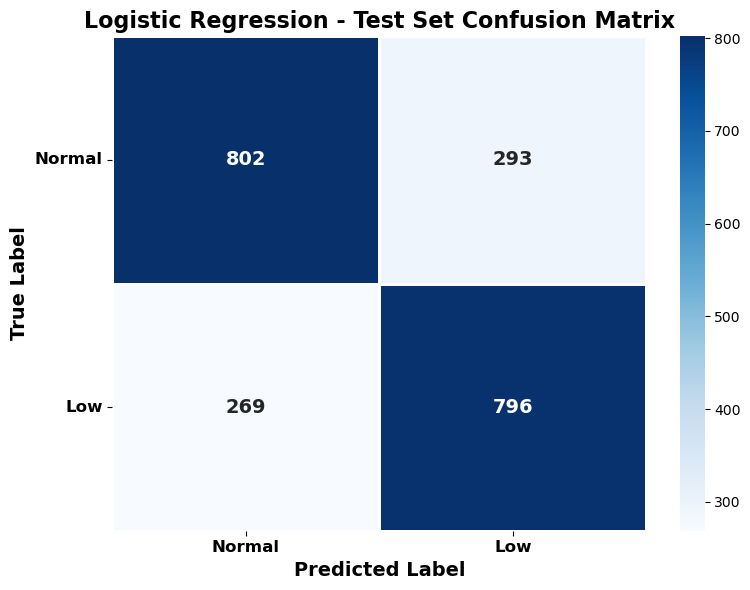


Classification Report:

              precision    recall  f1-score   support

      Normal      0.749     0.732     0.741      1095
         Low      0.731     0.747     0.739      1065

    accuracy                          0.740      2160
   macro avg      0.740     0.740     0.740      2160
weighted avg      0.740     0.740     0.740      2160



In [ ]:
# Confusion matrix hesapla
cm = confusion_matrix(y_test, y_pred)
class_names = ["Normal", "Low"]

# Görsel boyutu
plt.figure(figsize=(8, 6))

# Seaborn ile Confusion Matrix çizimi
sns.heatmap(cm,
            annot=True,          # Hücre içine sayı yaz
            fmt='d',             # Tam sayı formatı
            cmap='Blues',      # Logistic Regression için farklı renk paleti (isteğe bağlı)
            linewidths=2,        # Kare arası çizgi kalınlığı
            linecolor='white',   # Çizgi rengi
            xticklabels=class_names,
            yticklabels=class_names,
            cbar=True)           # Colorbar açık

# Başlık ve etiketler
plt.title("Logistic Regression - Test Set Confusion Matrix", fontsize=16, fontweight='bold')
plt.xlabel("Predicted Label", fontsize=14, fontweight='bold')
plt.ylabel("True Label", fontsize=14, fontweight='bold')

# Tick (eksende yazan sınıf isimleri) biçimi
plt.xticks(fontsize=12, fontweight='bold')
plt.yticks(fontsize=12, fontweight='bold', rotation=0)

# Hücre içindeki değerleri bold ve büyük yap
for text in plt.gca().texts:
    text.set_fontsize(14)
    text.set_fontweight('bold')

# Grafiği sıkı yerleştir
plt.tight_layout()

# 600 dpi olarak kaydet
plt.savefig("confusion_matrix_logreg.png", dpi=600, bbox_inches="tight")

# Göster
plt.show()

# Classification report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=class_names, digits=3))

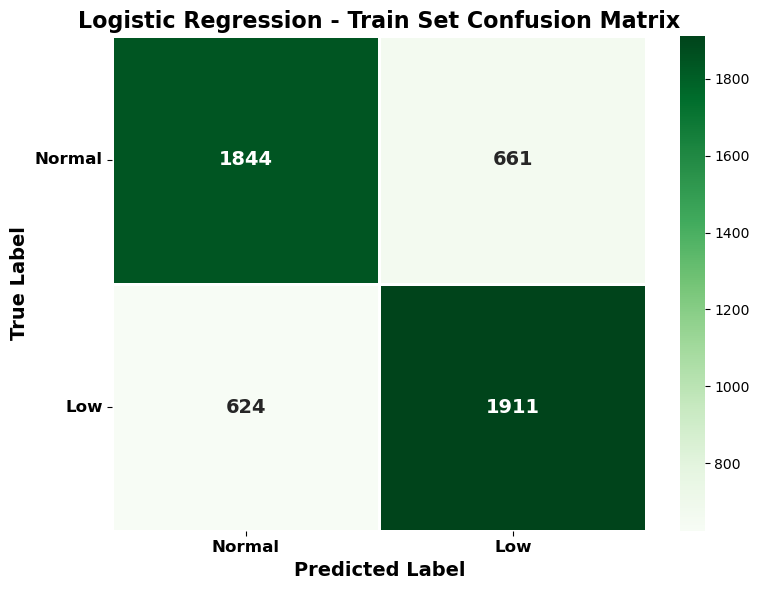


Classification Report (Train Set):

              precision    recall  f1-score   support

      Normal      0.747     0.736     0.742      2505
         Low      0.743     0.754     0.748      2535

    accuracy                          0.745      5040
   macro avg      0.745     0.745     0.745      5040
weighted avg      0.745     0.745     0.745      5040



In [ ]:
# Confusion matrix hesapla (Train set)
cm_train = confusion_matrix(y_train, y_pred_train)
class_names = ["Normal", "Low"]

# Görsel boyutu
plt.figure(figsize=(8, 6))

# Seaborn ile Confusion Matrix çizimi
sns.heatmap(cm_train,
            annot=True,          # Hücre içine sayı yaz
            fmt='d',             # Tam sayı formatı
            cmap='Greens',       # Yeşil tonları
            linewidths=2,        # Kare arası çizgi kalınlığı
            linecolor='white',   # Çizgi rengi
            xticklabels=class_names,
            yticklabels=class_names,
            cbar=True)           # Colorbar açık

# Başlık ve etiketler
plt.title("Logistic Regression - Train Set Confusion Matrix", fontsize=16, fontweight='bold')
plt.xlabel("Predicted Label", fontsize=14, fontweight='bold')
plt.ylabel("True Label", fontsize=14, fontweight='bold')

# Tick biçimi
plt.xticks(fontsize=12, fontweight='bold')
plt.yticks(fontsize=12, fontweight='bold', rotation=0)

# Hücre yazılarını kalınlaştır
for text in plt.gca().texts:
    text.set_fontsize(14)
    text.set_fontweight('bold')

# Grafiği sıkı yerleştir
plt.tight_layout()

# 600 dpi olarak kaydet
plt.savefig("confusion_matrix_logreg_train.png", dpi=600, bbox_inches="tight")

# Göster
plt.show()

# Classification report (Train)
print("\nClassification Report (Train Set):\n")
print(classification_report(y_train, y_pred_train, target_names=class_names, digits=3))

##### ROC Curve (Receiver Operating Characteristic)

In [ ]:
# Tahmin edilen olasılıklar
y_proba_logreg = logreg_final.predict_proba(X_test)[:, 1]

fpr_logreg, tpr_logreg, thresholds_logreg = roc_curve(y_test, y_proba_logreg)
roc_auc_logreg = auc(fpr_logreg, tpr_logreg)

##### Precision–Recall Curve (PR Curve)

In [ ]:
# Precision, Recall ve threshold değerlerini hesapla
precision_logreg, recall_logreg, thresholds_logreg_pr = precision_recall_curve(y_test, y_proba_logreg)
average_precision_logreg = average_precision_score(y_test, y_proba_logreg)

#### SVM

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

svc_model = SVC(random_state=17, probability=True)

svc_params = {"C": np.linspace(0.1, 2, 25), "gamma": ['scale', 'auto'] + list(np.linspace(0.1, 1, 10)), 'kernel' : ['rbf', 'linear']}
svc_cv_model = GridSearchCV(svc_model, svc_params, cv = 5, n_jobs=-1, verbose=1, scoring='f1')

svc_cv_model.fit(X_train,(y_train.values).ravel())
print('Best Params:\n',pd.Series(svc_cv_model.best_params_))

svc_final = svc_model.set_params(**svc_cv_model.best_params_)

svc_final.fit(X_train, (y_train.values).ravel())
y_pred = svc_final.predict(X_test)
y_proba = svc_final.predict_proba(X_test)[:, 1]

# Sonuclarin Degerlendirilmesi (Test Veri Seti)
print("*********** SVM - Test Set ***********")
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("AUC Score:",roc_auc_score(y_test,y_proba))

Fitting 5 folds for each of 600 candidates, totalling 3000 fits
Best Params:
 C        0.65417
gamma    0.20000
kernel       rbf
dtype: object
*********** SVM - Test Set ***********
Accuracy : 0.7550925925925925
Precision: 0.7427536231884058
Recall   : 0.7699530516431925
F1 Score : 0.756108805901337
AUC Score: 0.8237357171951036


In [ ]:
# Egitim veri setinde tahminler
y_pred_train = svc_final.predict(X_train)
y_proba_train = svc_final.predict_proba(X_train)[:, 1]


# Sonuclarin Egitim Veri Setinde Degerlendirilmesi
print("*********** SVM - Train Set ***********")
print("Accuracy :", accuracy_score(y_train, y_pred_train))
print("Precision:", precision_score(y_train, y_pred_train))
print("Recall   :", recall_score(y_train, y_pred_train))
print("F1 Score :", f1_score(y_train, y_pred_train))
print("AUC Score:", roc_auc_score(y_train, y_proba_train))

*********** SVM - Train Set ***********
Accuracy : 0.7777777777777778
Precision: 0.7713847334100499
Recall   : 0.7932938856015779
F1 Score : 0.7821859198755348
AUC Score: 0.8602782600479514


In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=17)
cv_results = cross_validate(svc_final, X_train, (y_train.values).ravel(), cv=cv, n_jobs=-1, scoring=["accuracy", "precision", "recall", "f1", "roc_auc"])

print("*********** SVM - Train Set (5-fold CV) ***********")
print("Accuracy :", cv_results['test_accuracy'].mean(), "\tStd", cv_results['test_accuracy'].std())
print("Precision:", cv_results['test_precision'].mean(), "\tStd", cv_results['test_precision'].std())
print("Recall   :", cv_results['test_recall'].mean(), "\tStd", cv_results['test_recall'].std())
print("F1       :", cv_results['test_f1'].mean(), "\tStd", cv_results['test_f1'].std())
print("ROC AUC  :", cv_results['test_roc_auc'].mean(), "\tStd", cv_results['test_roc_auc'].std())

*********** SVM - Train Set (5-fold CV) ***********
Accuracy : 0.7549603174603174 	Std 0.011518194661666661
Precision: 0.7487734950880275 	Std 0.015630502584815586
Recall   : 0.7723865877712032 	Std 0.009217610607927348
F1       : 0.7602982226668722 	Std 0.00965870099906332
ROC AUC  : 0.8304786875952237 	Std 0.009973814757963946


In [ ]:
svc_acc_scores = cv_results['test_accuracy']
svc_prec_scores = cv_results['test_precision']
svc_rec_scores  = cv_results['test_recall']
svc_f1_scores   = cv_results['test_f1']
svc_roc_scores  = cv_results['test_roc_auc']

print(" *********** SVM - 5-Fold CV Scores ***********")
print("Accuracy fold scores :", svc_acc_scores)
print("Precision fold scores:", svc_acc_scores)
print("Recall fold scores   :", svc_acc_scores)
print("F1 fold scores       :", svc_acc_scores)
print("ROC AUC fold scores  :", svc_acc_scores)

 *********** SVM - 5-Fold CV Scores ***********
Accuracy fold scores : [0.77678571 0.74900794 0.74305556 0.75198413 0.75396825]
Precision fold scores: [0.77678571 0.74900794 0.74305556 0.75198413 0.75396825]
Recall fold scores   : [0.77678571 0.74900794 0.74305556 0.75198413 0.75396825]
F1 fold scores       : [0.77678571 0.74900794 0.74305556 0.75198413 0.75396825]
ROC AUC fold scores  : [0.77678571 0.74900794 0.74305556 0.75198413 0.75396825]


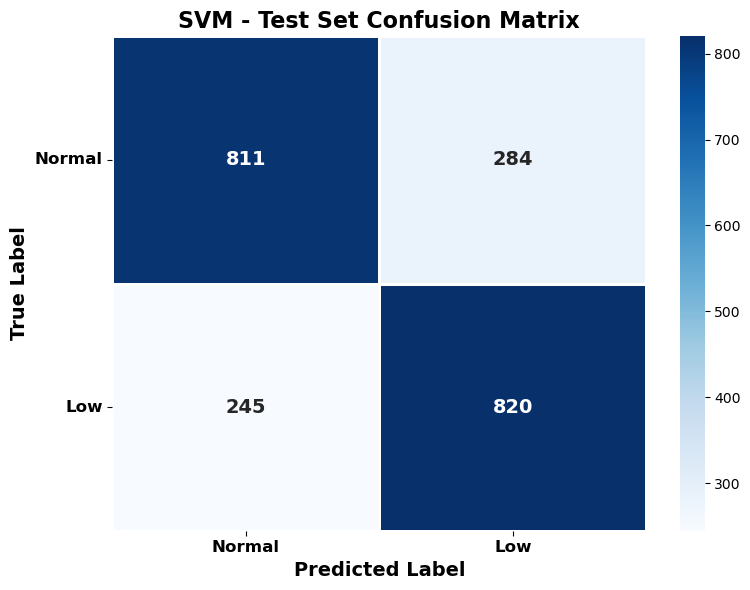


Classification Report:

              precision    recall  f1-score   support

      Normal      0.768     0.741     0.754      1095
         Low      0.743     0.770     0.756      1065

    accuracy                          0.755      2160
   macro avg      0.755     0.755     0.755      2160
weighted avg      0.756     0.755     0.755      2160



In [ ]:
# Confusion matrix hesapla
cm = confusion_matrix(y_test, y_pred)
class_names = ["Normal", "Low"]

# Görsel boyutu
plt.figure(figsize=(8, 6))

# Seaborn ile Confusion Matrix çizimi
sns.heatmap(cm,
            annot=True,          # Hücre içine sayı yaz
            fmt='d',             # Tam sayı formatı
            cmap='Blues',      # Logistic Regression için farklı renk paleti (isteğe bağlı)
            linewidths=2,        # Kare arası çizgi kalınlığı
            linecolor='white',   # Çizgi rengi
            xticklabels=class_names,
            yticklabels=class_names,
            cbar=True)           # Colorbar açık

# Başlık ve etiketler
plt.title("SVM - Test Set Confusion Matrix", fontsize=16, fontweight='bold')
plt.xlabel("Predicted Label", fontsize=14, fontweight='bold')
plt.ylabel("True Label", fontsize=14, fontweight='bold')

# Tick (eksende yazan sınıf isimleri) biçimi
plt.xticks(fontsize=12, fontweight='bold')
plt.yticks(fontsize=12, fontweight='bold', rotation=0)

# Hücre içindeki değerleri bold ve büyük yap
for text in plt.gca().texts:
    text.set_fontsize(14)
    text.set_fontweight('bold')

# Grafiği sıkı yerleştir
plt.tight_layout()

# 600 dpi olarak kaydet
plt.savefig("confusion_matrix_svm.png", dpi=600, bbox_inches="tight")

# Göster
plt.show()

# Classification report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=class_names, digits=3))

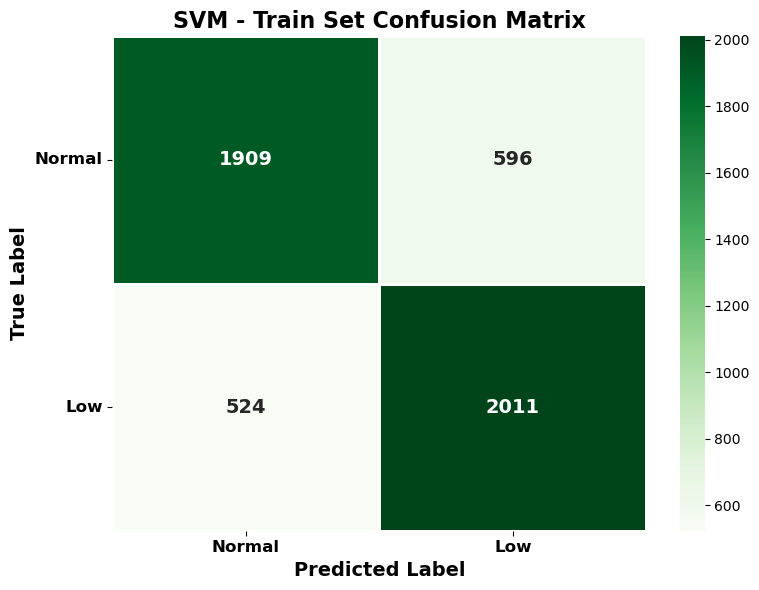


Classification Report (Train Set):

              precision    recall  f1-score   support

      Normal      0.785     0.762     0.773      2505
         Low      0.771     0.793     0.782      2535

    accuracy                          0.778      5040
   macro avg      0.778     0.778     0.778      5040
weighted avg      0.778     0.778     0.778      5040



In [ ]:
# Confusion matrix (Train set)
cm_train = confusion_matrix(y_train, y_pred_train)
class_names = ["Normal", "Low"]

# Görsel boyutu
plt.figure(figsize=(8, 6))

# Seaborn ile Confusion Matrix çizimi (yeşil tonlarında)
sns.heatmap(cm_train,
            annot=True,          # Hücre içine sayı yaz
            fmt='d',             # Tam sayı formatı
            cmap='Greens',       # Yeşil tonları
            linewidths=2,        # Kare arası çizgi kalınlığı
            linecolor='white',   # Çizgi rengi
            xticklabels=class_names,
            yticklabels=class_names,
            cbar=True)           # Colorbar açık

# Başlık ve etiketler
plt.title("SVM - Train Set Confusion Matrix", fontsize=16, fontweight='bold')
plt.xlabel("Predicted Label", fontsize=14, fontweight='bold')
plt.ylabel("True Label", fontsize=14, fontweight='bold')

# Tick (eksende yazan sınıf isimleri) biçimi
plt.xticks(fontsize=12, fontweight='bold')
plt.yticks(fontsize=12, fontweight='bold', rotation=0)

# Hücre içindeki değerleri bold ve büyük yap
for text in plt.gca().texts:
    text.set_fontsize(14)
    text.set_fontweight('bold')

# Grafiği sıkı yerleştir
plt.tight_layout()

# 600 dpi olarak kaydet
plt.savefig("confusion_matrix_svm_train.png", dpi=600, bbox_inches="tight")

# Göster
plt.show()

# Classification report (Train)
print("\nClassification Report (Train Set):\n")
print(classification_report(y_train, y_pred_train, target_names=class_names, digits=3))

##### ROC Curve (Receiver Operating Characteristic)

In [ ]:
# Tahmin edilen olasılıklar
y_proba_svc = svc_final.predict_proba(X_test)[:, 1]

fpr_svc, tpr_svc, thresholds_svc = roc_curve(y_test, y_proba_svc)
roc_auc_svc = auc(fpr_svc, tpr_svc)

##### Precision–Recall Curve (PR Curve)

In [ ]:
# Precision, Recall ve threshold değerlerini hesapla
precision_svc, recall_svc, thresholds_svc_pr = precision_recall_curve(y_test, y_proba_svc)
average_precision_svc = average_precision_score(y_test, y_proba_svc)

#### Random Forests

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# Model ve parametreler
rf_model = RandomForestClassifier(random_state=17)
rf_params = {"max_depth": [5, 8, None],
             "max_features": [1, 3, 5, 7, "sqrt"],
             "min_samples_split": [2, 5, 8, 15, 20],
             "n_estimators": [100, 200, 500]}

# GridSearchCV
rf_cv_model = GridSearchCV(rf_model, rf_params, cv=5, n_jobs=-1, verbose=True, scoring='f1')
rf_cv_model.fit(X_train, (y_train.values).ravel())

# En iyi parametreler
print('Best Params:', rf_cv_model.best_params_)

# Final model
rf_final = rf_model.set_params(**rf_cv_model.best_params_, random_state=17)
rf_final.fit(X_train, (y_train.values).ravel())

# Tahminler
y_pred = rf_final.predict(X_test)
y_proba = rf_final.predict_proba(X_test)[:, 1]

# Sonuclarin Degerlendirilmesi (Test Veri Seti)
print("*********** Random Forest - Test Set ***********")
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("AUC Score:",roc_auc_score(y_test,y_proba))

Fitting 5 folds for each of 225 candidates, totalling 1125 fits
Best Params: {'max_depth': None, 'max_features': 1, 'min_samples_split': 8, 'n_estimators': 500}
*********** Random Forest - Test Set ***********
Accuracy : 0.7481481481481481
Precision: 0.7418755803156918
Recall   : 0.7502347417840376
F1 Score : 0.746031746031746
AUC Score: 0.8316384762149763


In [ ]:
# Egitim veri setinde tahminler
y_pred_train = rf_final.predict(X_train)
y_proba_train = rf_final.predict_proba(X_train)[:, 1]

# Sonuclarin Egitim Veri Setinde Degerlendirilmesi
print("*********** Random Forest - Train Set ***********")
print("Accuracy :", accuracy_score(y_train, y_pred_train))
print("Precision:", precision_score(y_train, y_pred_train))
print("Recall   :", recall_score(y_train, y_pred_train))
print("F1 Score :", f1_score(y_train, y_pred_train))
print("AUC Score:", roc_auc_score(y_train, y_proba_train))

*********** Random Forest - Train Set ***********
Accuracy : 0.9563492063492064
Precision: 0.9555293191656828
Recall   : 0.9577909270216962
F1 Score : 0.9566587864460205
AUC Score: 0.993456715759802


In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=17)
cv_results = cross_validate(rf_final, X_train, (y_train.values).ravel(), cv=cv, n_jobs=-1, scoring=["accuracy", "precision", "recall", "f1", "roc_auc"])

print("*********** Random Forest - Train Set (5-fold CV) ***********")
print("Accuracy :", cv_results['test_accuracy'].mean(), "\tStd", cv_results['test_accuracy'].std())
print("Precision:", cv_results['test_precision'].mean(), "\t\t\tStd", cv_results['test_precision'].std())
print("Recall   :", cv_results['test_recall'].mean(), "\tStd", cv_results['test_recall'].std())
print("F1       :", cv_results['test_f1'].mean(), "\tStd", cv_results['test_f1'].std())
print("ROC AUC  :", cv_results['test_roc_auc'].mean(), "\t\t\tStd", cv_results['test_roc_auc'].std())

*********** Random Forest - Train Set (5-fold CV) ***********
Accuracy : 0.755952380952381 	Std 0.0076588329625471374
Precision: 0.7588679972377617 			Std 0.012469374003830679
Recall   : 0.7550295857988165 	Std 0.004566405089858064
F1       : 0.756866069974097 	Std 0.005442740512320961
ROC AUC  : 0.837090316408603 			Std 0.010713093998450017


In [ ]:
rf_acc_scores = cv_results['test_accuracy']
rf_prec_scores = cv_results['test_precision']
rf_rec_scores  = cv_results['test_recall']
rf_f1_scores   = cv_results['test_f1']
rf_roc_scores  = cv_results['test_roc_auc']

print(" *********** Random Forests - 5-Fold CV Scores ***********")
print("Accuracy fold scores :", rf_acc_scores)
print("Precision fold scores:", rf_prec_scores)
print("Recall fold scores   :", rf_rec_scores)
print("F1 fold scores       :", rf_f1_scores)
print("ROC AUC fold scores  :", rf_roc_scores)

 *********** Random Forests - 5-Fold CV Scores ***********
Accuracy fold scores : [0.75793651 0.75992063 0.74305556 0.75297619 0.76587302]
Precision fold scores: [0.76143141 0.76341948 0.73664122 0.758      0.77484787]
Recall fold scores   : [0.75542406 0.75739645 0.76134122 0.74753452 0.75345168]
F1 fold scores       : [0.75841584 0.76039604 0.74878758 0.75273088 0.764     ]
ROC AUC fold scores  : [0.84467751 0.8386698  0.81760345 0.83589429 0.84860653]


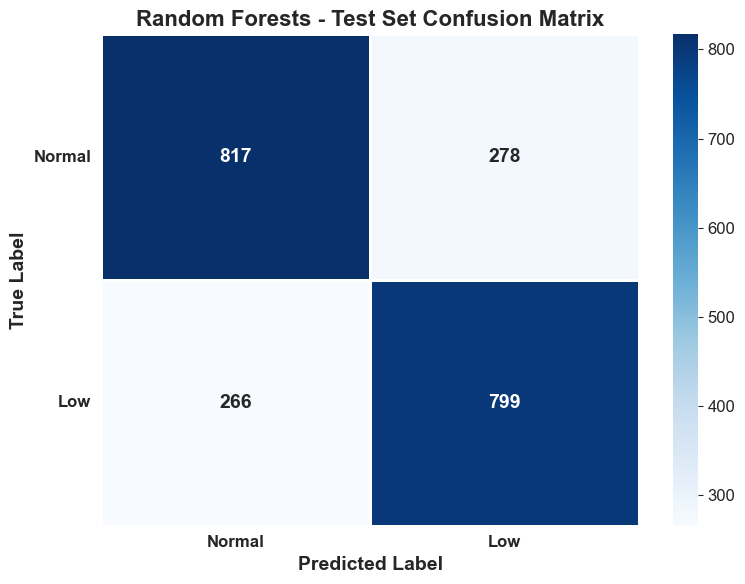


Classification Report:

              precision    recall  f1-score   support

      Normal      0.754     0.746     0.750      1095
         Low      0.742     0.750     0.746      1065

    accuracy                          0.748      2160
   macro avg      0.748     0.748     0.748      2160
weighted avg      0.748     0.748     0.748      2160



In [ ]:
# Confusion matrix hesapla
cm = confusion_matrix(y_test, y_pred)
class_names = ["Normal", "Low"]

# Görsel boyutu
plt.figure(figsize=(8, 6))

# Seaborn ile Confusion Matrix çizimi
sns.heatmap(cm,
            annot=True,          # Hücre içine sayı yaz
            fmt='d',             # Tam sayı formatı
            cmap='Blues',      # Logistic Regression için farklı renk paleti (isteğe bağlı)
            linewidths=2,        # Kare arası çizgi kalınlığı
            linecolor='white',   # Çizgi rengi
            xticklabels=class_names,
            yticklabels=class_names,
            cbar=True)           # Colorbar açık

# Başlık ve etiketler
plt.title("Random Forests - Test Set Confusion Matrix", fontsize=16, fontweight='bold')
plt.xlabel("Predicted Label", fontsize=14, fontweight='bold')
plt.ylabel("True Label", fontsize=14, fontweight='bold')

# Tick (eksende yazan sınıf isimleri) biçimi
plt.xticks(fontsize=12, fontweight='bold')
plt.yticks(fontsize=12, fontweight='bold', rotation=0)

# Hücre içindeki değerleri bold ve büyük yap
for text in plt.gca().texts:
    text.set_fontsize(14)
    text.set_fontweight('bold')

# Grafiği sıkı yerleştir
plt.tight_layout()

# 600 dpi olarak kaydet
plt.savefig("confusion_matrix_rf.png", dpi=600, bbox_inches="tight")

# Göster
plt.show()

# Classification report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=class_names, digits=3))

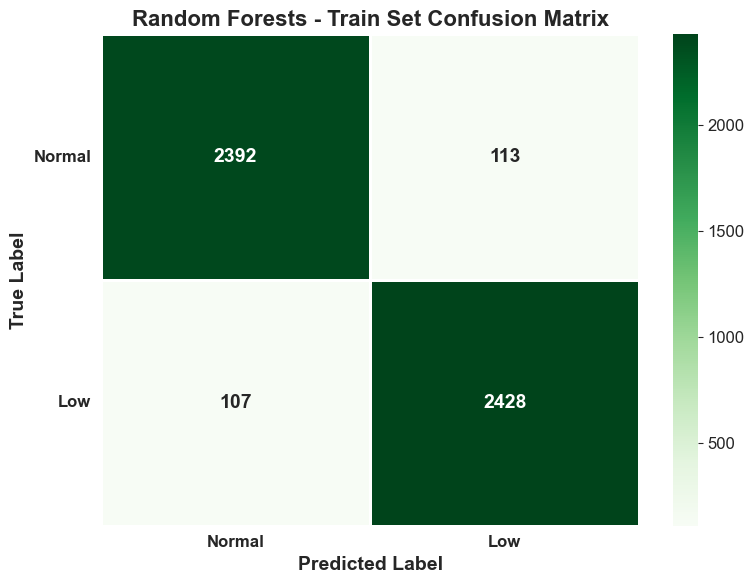


Classification Report (Train Set):

              precision    recall  f1-score   support

      Normal      0.957     0.955     0.956      2505
         Low      0.956     0.958     0.957      2535

    accuracy                          0.956      5040
   macro avg      0.956     0.956     0.956      5040
weighted avg      0.956     0.956     0.956      5040



In [ ]:
# Confusion matrix (Train set)
cm_train = confusion_matrix(y_train, y_pred_train)
class_names = ["Normal", "Low"]

# Görsel boyutu
plt.figure(figsize=(8, 6))

# Seaborn ile Confusion Matrix çizimi (yeşil tonlarında)
sns.heatmap(cm_train,
            annot=True,          # Hücre içine sayı yaz
            fmt='d',             # Tam sayı formatı
            cmap='Greens',       # Yeşil tonları
            linewidths=2,        # Kare arası çizgi kalınlığı
            linecolor='white',   # Çizgi rengi
            xticklabels=class_names,
            yticklabels=class_names,
            cbar=True)           # Colorbar açık

# Başlık ve etiketler
plt.title("Random Forests - Train Set Confusion Matrix", fontsize=16, fontweight='bold')
plt.xlabel("Predicted Label", fontsize=14, fontweight='bold')
plt.ylabel("True Label", fontsize=14, fontweight='bold')

# Tick (eksende yazan sınıf isimleri) biçimi
plt.xticks(fontsize=12, fontweight='bold')
plt.yticks(fontsize=12, fontweight='bold', rotation=0)

# Hücre içindeki değerleri bold ve büyük yap
for text in plt.gca().texts:
    text.set_fontsize(14)
    text.set_fontweight('bold')

# Grafiği sıkı yerleştir
plt.tight_layout()

# 600 dpi olarak kaydet
plt.savefig("confusion_matrix_rf_train.png", dpi=600, bbox_inches="tight")

# Göster
plt.show()

# Classification report (Train)
print("\nClassification Report (Train Set):\n")
print(classification_report(y_train, y_pred_train, target_names=class_names, digits=3))

##### ROC Curve (Receiver Operating Characteristic)

In [ ]:
# Tahmin edilen olasılıklar
y_proba_rf = rf_final.predict_proba(X_test)[:, 1]

fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_proba_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

##### Precision–Recall Curve (PR Curve)

In [ ]:
# Precision, Recall ve threshold değerlerini hesapla
precision_rf, recall_rf, thresholds_rf_pr = precision_recall_curve(y_test, y_proba_rf)
average_precision_rf = average_precision_score(y_test, y_proba_rf)

##### Feature Importances

In [ ]:
feature_scores = pd.Series(rf_final.feature_importances_, index=X_train.columns).sort_values(ascending=False)

feature_scores

MCH      0.14626
HGB      0.14233
Age      0.12970
HCT      0.12472
MCV      0.12015
RDW-CV   0.11724
WBC      0.08174
MPV      0.07159
Sex      0.06627
dtype: float64

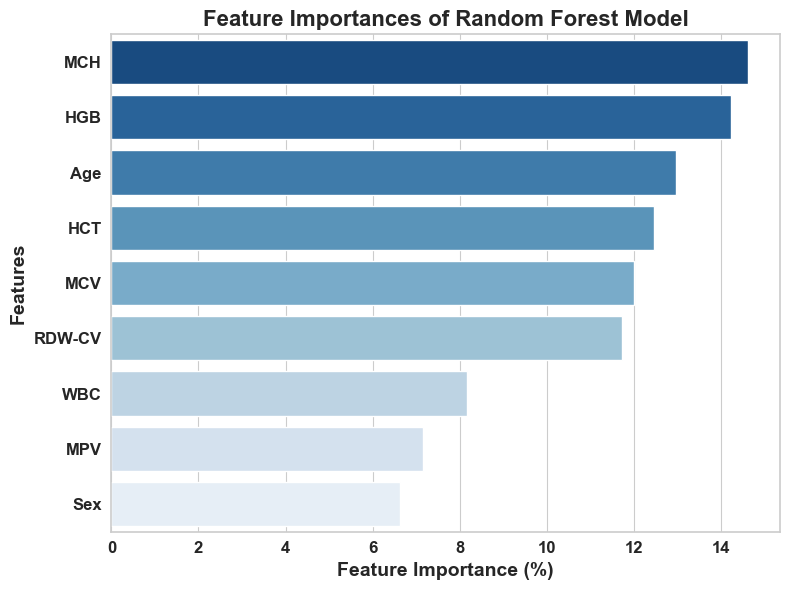

In [ ]:
# Normalize edip % hesapla
feature_scores_percent = 100 * feature_scores / feature_scores.sum()

plt.figure(figsize=(8,6))
sns.set_style("whitegrid", {'axes.grid': True, 'axes.grid.axis': 'y'})

ax = sns.barplot(
    x=feature_scores_percent, y=feature_scores_percent.index,
    palette="Blues_r"
)

plt.title("Feature Importances of Random Forest Model", fontsize=16, fontweight="bold")
plt.xlabel("Feature Importance (%)", fontsize=14, fontweight="bold")
plt.ylabel("Features", fontsize=14, fontweight="bold")

plt.xticks(fontsize=12, fontweight="bold")
plt.yticks(fontsize=12, fontweight="bold")

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.2)

plt.tight_layout()
plt.savefig("rf_feature_importances_percent.png", dpi=600, bbox_inches="tight")
plt.show()

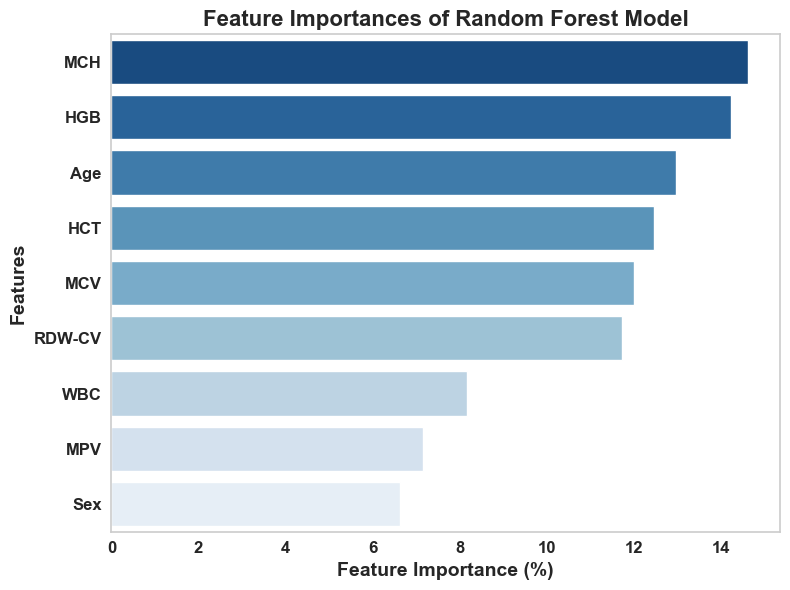

In [ ]:
plt.figure(figsize=(8,6))
sns.set_style("whitegrid", {'axes.grid': False, 'axes.grid.axis': 'y'})

ax = sns.barplot(
    x=feature_scores_percent, y=feature_scores_percent.index,
    palette="Blues_r"
)

plt.title("Feature Importances of Random Forest Model", fontsize=16, fontweight="bold")
plt.xlabel("Feature Importance (%)", fontsize=14, fontweight="bold")
plt.ylabel("Features", fontsize=14, fontweight="bold")

plt.xticks(fontsize=12, fontweight="bold")
plt.yticks(fontsize=12, fontweight="bold")

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.2)

plt.tight_layout()
plt.savefig("rf_feature_importances_percent_2.png", dpi=600, bbox_inches="tight")
plt.show()

#### XGBoost

In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

# Model ve parametreler
xgb_model = XGBClassifier(random_state=17, eval_metric="logloss", n_jobs=-1, tree_method="hist")
xgb_params = {'colsample_bytree': [0.4, 0.5, 0.6, 1],
              'n_estimators': [100, 150, 200, 500],
              'max_depth': [5, 8, 10, 15, 20],
              'learning_rate': [0.01, 0.1, 0.3, 0.5]}

# GridSearchCV
xgb_cv_model = GridSearchCV(xgb_model, xgb_params, cv=5, n_jobs=-1, verbose=True, scoring='f1')
xgb_cv_model.fit(X_train, (y_train.values).ravel())

# En iyi parametreler
print('Best Params:', xgb_cv_model.best_params_)

# Final model
xgb_final = xgb_model.set_params(**xgb_cv_model.best_params_, random_state=17).fit(X_train, (y_train.values).ravel())

# Tahminler
y_pred = xgb_final.predict(X_test)
y_proba = xgb_final.predict_proba(X_test)[:, 1]

# Sonuclarin Degerlendirilmesi (Test Veri Seti)
print("*********** XGBoost - Test Set ***********")
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("AUC Score:",roc_auc_score(y_test,y_proba))

Fitting 5 folds for each of 320 candidates, totalling 1600 fits
Best Params: {'colsample_bytree': 1, 'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 500}
*********** XGBoost - Test Set ***********
Accuracy : 0.7564814814814815
Precision: 0.7502321262766946
Recall   : 0.7586854460093897
F1 Score : 0.7544351073762838
AUC Score: 0.8348266769567174


In [ ]:
# Egitim veri setinde tahminler
y_pred_train = xgb_final.predict(X_train)
y_proba_train = xgb_final.predict_proba(X_train)[:, 1]

# Sonuclarin Egitim Veri Setinde Degerlendirilmesi
print("*********** XGBoost - Train Set ***********")
print("Accuracy :", accuracy_score(y_train, y_pred_train))
print("Precision:", precision_score(y_train, y_pred_train))
print("Recall   :", recall_score(y_train, y_pred_train))
print("F1 Score :", f1_score(y_train, y_pred_train))
print("AUC Score:", roc_auc_score(y_train, y_proba_train))

*********** XGBoost - Train Set ***********
Accuracy : 0.814484126984127
Precision: 0.812256049960968
Recall   : 0.8209072978303747
F1 Score : 0.8165587600549343
AUC Score: 0.9000529906656115


In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=17)
cv_results = cross_validate(xgb_final, X_train, (y_train.values).ravel(), cv=cv, n_jobs=-1, scoring=["accuracy", "precision", "recall", "f1", "roc_auc"])

print("*********** XGBoost - Train Set (5-fold CV) ***********")
print("Accuracy :", cv_results['test_accuracy'].mean(), "\tStd", cv_results['test_accuracy'].std())
print("Precision:", cv_results['test_precision'].mean(), "\t\t\tStd", cv_results['test_precision'].std())
print("Recall   :", cv_results['test_recall'].mean(), "\tStd", cv_results['test_recall'].std())
print("F1       :", cv_results['test_f1'].mean(), "\tStd", cv_results['test_f1'].std())
print("ROC AUC  :", cv_results['test_roc_auc'].mean(), "\tStd", cv_results['test_roc_auc'].std())


*********** XGBoost - Train Set (5-fold CV) ***********
Accuracy : 0.7581349206349206 	Std 0.006710926398923691
Precision: 0.7552170125612142 			Std 0.009889781978736824
Recall   : 0.7684418145956606 	Std 0.01160863035073936
F1       : 0.7616712013036246 	Std 0.006352828945372078
ROC AUC  : 0.8371804714043314 	Std 0.008869834959918426


In [ ]:
xgb_acc_scores = cv_results['test_accuracy']
xgb_prec_scores = cv_results['test_precision']
xgb_rec_scores  = cv_results['test_recall']
xgb_f1_scores   = cv_results['test_f1']
xgb_roc_scores  = cv_results['test_roc_auc']

print(" *********** XGBoost - 5-Fold CV Scores ***********")

print("Accuracy fold scores :", xgb_acc_scores)
print("Precision fold scores:", xgb_prec_scores)
print("Recall fold scores   :", xgb_rec_scores)
print("F1 fold scores       :", xgb_f1_scores)
print("ROC AUC fold scores  :", xgb_roc_scores)

 *********** XGBoost - 5-Fold CV Scores ***********
Accuracy fold scores : [0.75793651 0.75793651 0.74603175 0.76388889 0.76488095]
Precision fold scores: [0.76565657 0.75435203 0.73724008 0.75619048 0.76264591]
Recall fold scores   : [0.74753452 0.76923077 0.76923077 0.78303748 0.77317554]
F1 fold scores       : [0.75648703 0.76171875 0.75289575 0.76937984 0.76787463]
ROC AUC fold scores  : [0.84691367 0.83658324 0.82172932 0.83588838 0.84478774]


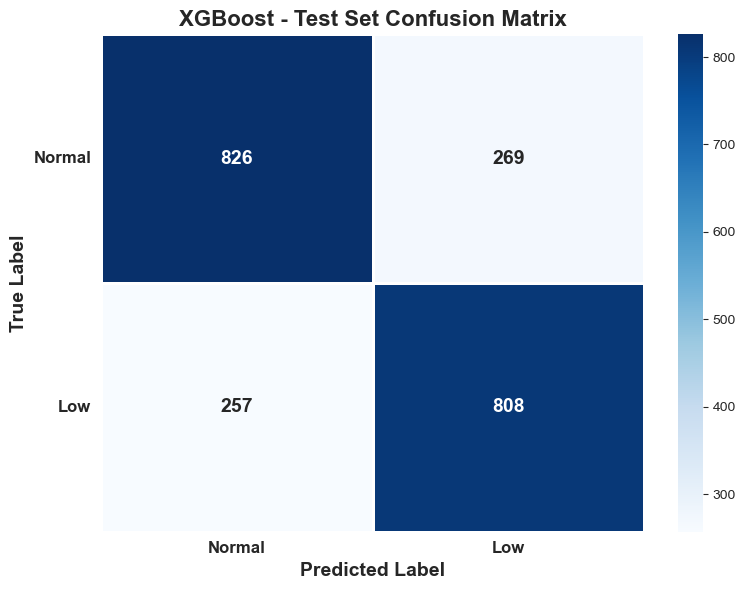


Classification Report:

              precision    recall  f1-score   support

      Normal      0.763     0.754     0.758      1095
         Low      0.750     0.759     0.754      1065

    accuracy                          0.756      2160
   macro avg      0.756     0.757     0.756      2160
weighted avg      0.757     0.756     0.756      2160



In [ ]:
# Confusion matrix hesapla
cm = confusion_matrix(y_test, y_pred)
class_names = ["Normal", "Low"]

# Görsel boyutu
plt.figure(figsize=(8, 6))

# Seaborn ile Confusion Matrix çizimi
sns.heatmap(cm,
            annot=True,          # Hücre içine sayı yaz
            fmt='d',             # Tam sayı formatı
            cmap='Blues',      # Logistic Regression için farklı renk paleti (isteğe bağlı)
            linewidths=2,        # Kare arası çizgi kalınlığı
            linecolor='white',   # Çizgi rengi
            xticklabels=class_names,
            yticklabels=class_names,
            cbar=True)           # Colorbar açık

# Başlık ve etiketler
plt.title("XGBoost - Test Set Confusion Matrix", fontsize=16, fontweight='bold')
plt.xlabel("Predicted Label", fontsize=14, fontweight='bold')
plt.ylabel("True Label", fontsize=14, fontweight='bold')

# Tick (eksende yazan sınıf isimleri) biçimi
plt.xticks(fontsize=12, fontweight='bold')
plt.yticks(fontsize=12, fontweight='bold', rotation=0)

# Hücre içindeki değerleri bold ve büyük yap
for text in plt.gca().texts:
    text.set_fontsize(14)
    text.set_fontweight('bold')

# Grafiği sıkı yerleştir
plt.tight_layout()

# 600 dpi olarak kaydet
plt.savefig("confusion_matrix_xgboost.png", dpi=600, bbox_inches="tight")

# Göster
plt.show()

# Classification report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=class_names, digits=3))

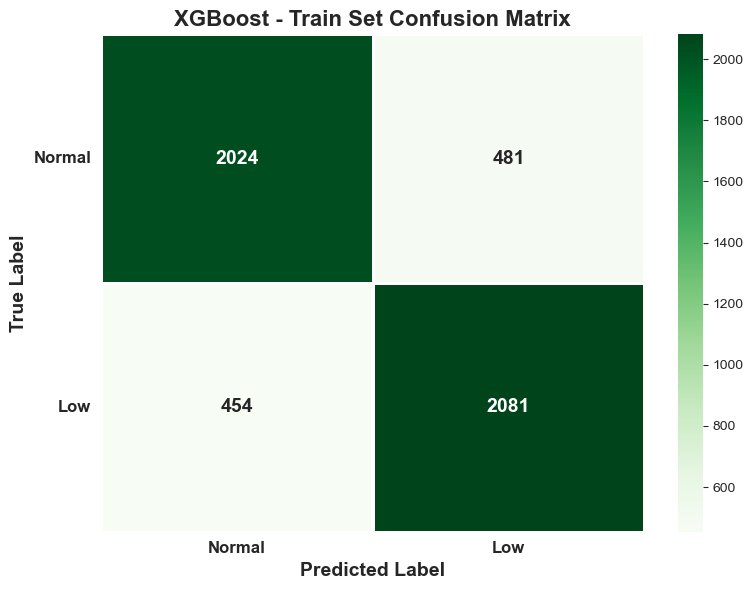


Classification Report (Train Set):

              precision    recall  f1-score   support

      Normal      0.817     0.808     0.812      2505
         Low      0.812     0.821     0.817      2535

    accuracy                          0.814      5040
   macro avg      0.815     0.814     0.814      5040
weighted avg      0.815     0.814     0.814      5040



In [ ]:
# Confusion matrix (Train set)
cm_train = confusion_matrix(y_train, y_pred_train)
class_names = ["Normal", "Low"]

# Görsel boyutu
plt.figure(figsize=(8, 6))

# Seaborn ile Confusion Matrix çizimi (yeşil tonlarında)
sns.heatmap(cm_train,
            annot=True,          # Hücre içine sayı yaz
            fmt='d',             # Tam sayı formatı
            cmap='Greens',       # Yeşil tonları
            linewidths=2,        # Kare arası çizgi kalınlığı
            linecolor='white',   # Çizgi rengi
            xticklabels=class_names,
            yticklabels=class_names,
            cbar=True)           # Colorbar açık

# Başlık ve etiketler
plt.title("XGBoost - Train Set Confusion Matrix", fontsize=16, fontweight='bold')
plt.xlabel("Predicted Label", fontsize=14, fontweight='bold')
plt.ylabel("True Label", fontsize=14, fontweight='bold')

# Tick (eksende yazan sınıf isimleri) biçimi
plt.xticks(fontsize=12, fontweight='bold')
plt.yticks(fontsize=12, fontweight='bold', rotation=0)

# Hücre içindeki değerleri bold ve büyük yap
for text in plt.gca().texts:
    text.set_fontsize(14)
    text.set_fontweight('bold')

# Grafiği sıkı yerleştir
plt.tight_layout()

# 600 dpi olarak kaydet
plt.savefig("confusion_matrix_xgboost_train.png", dpi=600, bbox_inches="tight")

# Göster
plt.show()

# Classification report (Train)
print("\nClassification Report (Train Set):\n")
print(classification_report(y_train, y_pred_train, target_names=class_names, digits=3))

##### ROC Curve (Receiver Operating Characteristic)

In [ ]:
# Tahmin edilen olasılıklar
y_proba_xgb = xgb_final.predict_proba(X_test)[:, 1]

fpr_xgb, tpr_xgb, thresholds_xgb = roc_curve(y_test, y_proba_xgb)
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)

##### Precision–Recall Curve (PR Curve)

In [ ]:
# Precision, Recall ve threshold değerlerini hesapla
precision_xgb, recall_xgb, thresholds_xgb_pr = precision_recall_curve(y_test, y_proba_xgb)
average_precision_xgb = average_precision_score(y_test, y_proba_xgb)

##### Feature Importances

In [ ]:
feature_scores = pd.Series(xgb_final.feature_importances_, index=X_train.columns).sort_values(ascending=False)

feature_scores

HGB      0.32740
Sex      0.18461
MCH      0.16147
Age      0.11281
RDW-CV   0.06601
HCT      0.03964
MCV      0.03893
WBC      0.03516
MPV      0.03397
dtype: float32

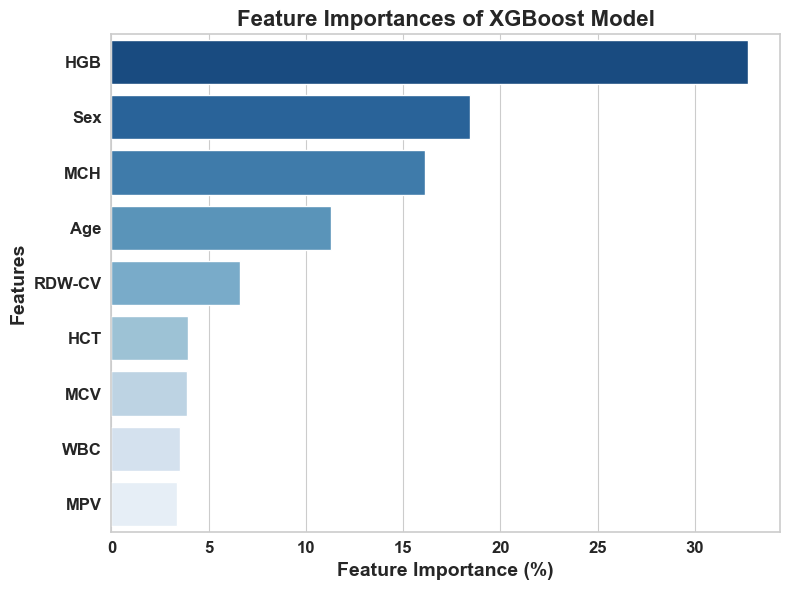

In [ ]:
# Normalize edip % hesapla
feature_scores_percent = 100 * feature_scores / feature_scores.sum()

plt.figure(figsize=(8,6))
sns.set_style("whitegrid", {'axes.grid': True, 'axes.grid.axis': 'y'})

ax = sns.barplot(
    x=feature_scores_percent, y=feature_scores_percent.index,
    palette="Blues_r"
)

plt.title("Feature Importances of XGBoost Model", fontsize=16, fontweight="bold")
plt.xlabel("Feature Importance (%)", fontsize=14, fontweight="bold")
plt.ylabel("Features", fontsize=14, fontweight="bold")

plt.xticks(fontsize=12, fontweight="bold")
plt.yticks(fontsize=12, fontweight="bold")

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.2)

plt.tight_layout()
plt.savefig("xgb_feature_importances_percent.png", dpi=600, bbox_inches="tight")
plt.show()

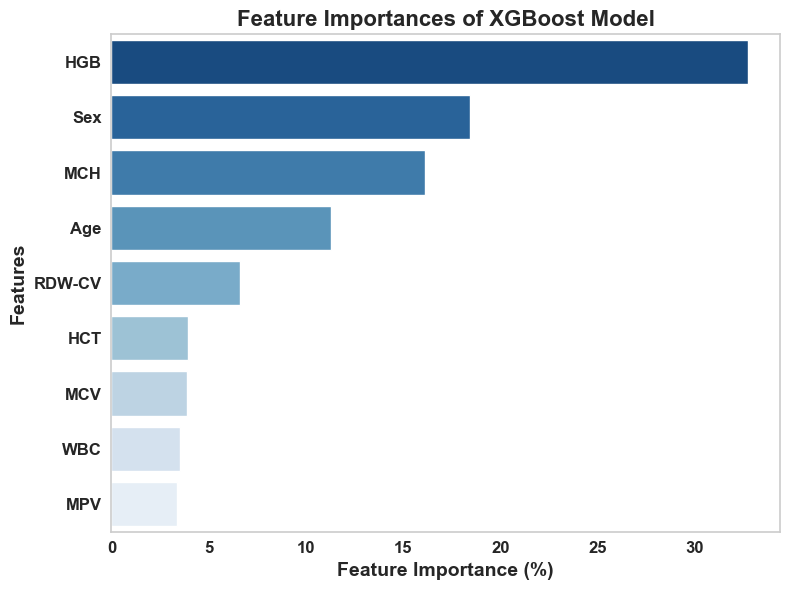

In [ ]:
plt.figure(figsize=(8,6))
sns.set_style("whitegrid", {'axes.grid': False, 'axes.grid.axis': 'y'})

ax = sns.barplot(
    x=feature_scores_percent, y=feature_scores_percent.index,
    palette="Blues_r"
)

plt.title("Feature Importances of XGBoost Model", fontsize=16, fontweight="bold")
plt.xlabel("Feature Importance (%)", fontsize=14, fontweight="bold")
plt.ylabel("Features", fontsize=14, fontweight="bold")

plt.xticks(fontsize=12, fontweight="bold")
plt.yticks(fontsize=12, fontweight="bold")

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.2)

plt.tight_layout()
plt.savefig("xgb_feature_importances_percent_2.png", dpi=600, bbox_inches="tight")
plt.show()

#### ROC and PR Curve Visualization

In [ ]:
# === ANN ROC ve PR verilerini oku ===
roc_ann = pd.read_excel("ANN_ROC_PR_curves.xlsx", sheet_name="ROC")
pr_ann  = pd.read_excel("ANN_ROC_PR_curves.xlsx", sheet_name="PR")

# === ROC verileri ===
fpr_ann = roc_ann["FPR"].values
tpr_ann = roc_ann["TPR"].values
roc_auc_ann = auc(fpr_ann, tpr_ann)

# === PR verileri ===
precision_ann = pr_ann["Precision"].values
recall_ann = pr_ann["Recall"].values

# average_precision_ann değerini Excel'de yoksa kendin hesaplayabilirsin:
average_precision_ann = auc(recall_ann, precision_ann)

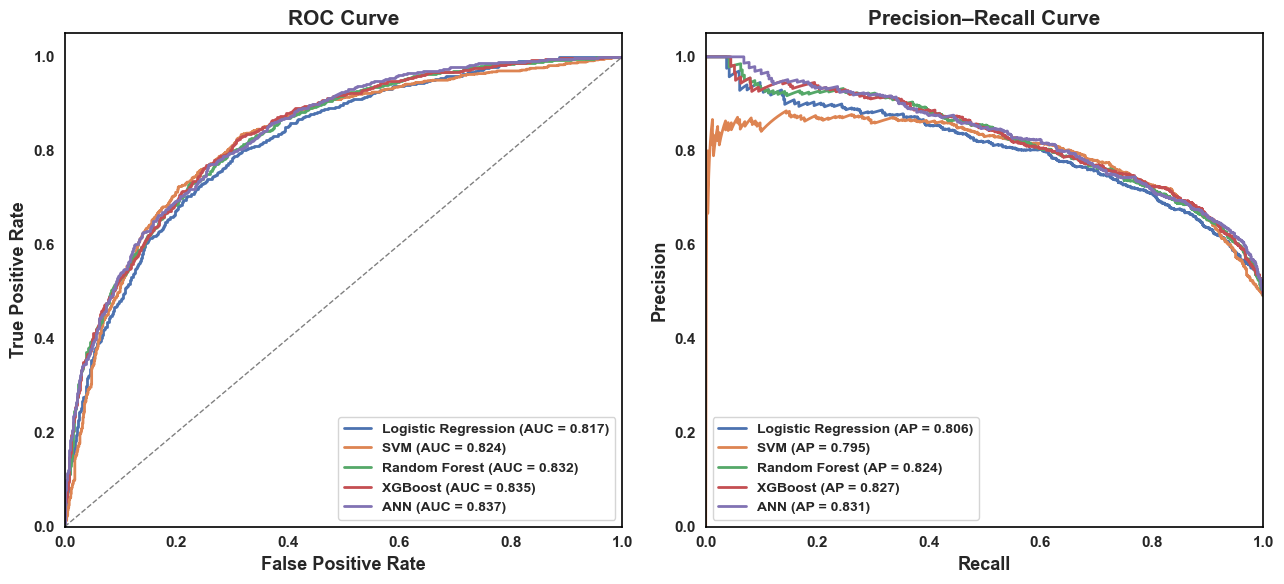

In [ ]:
# === Nature uyumlu renk paleti ===
colors = {
    "Logistic Regression": "#4C72B0",  # mavi
    "SVM": "#DD8452",                  # turuncu
    "Random Forest": "#55A868",        # yeşil
    "XGBoost": "#C44E52",              # kırmızı
    "ANN": "#8172B3"                   # mor
}

# === Model listesi ===
models = ["Logistic Regression", "SVM", "Random Forest", "XGBoost", "ANN"]

# === ROC verileri ===
fpr_list = [fpr_logreg, fpr_svc, fpr_rf, fpr_xgb, fpr_ann]
tpr_list = [tpr_logreg, tpr_svc, tpr_rf, tpr_xgb, tpr_ann]
auc_list = [roc_auc_logreg, roc_auc_svc, roc_auc_rf, roc_auc_xgb, roc_auc_ann]

# === PR verileri ===
precision_list = [precision_logreg, precision_svc, precision_rf, precision_xgb, precision_ann]
recall_list = [recall_logreg, recall_svc, recall_rf, recall_xgb, recall_ann]
ap_list = [average_precision_logreg, average_precision_svc, average_precision_rf, average_precision_xgb, average_precision_ann]

# === Şekil ayarları ===
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
plt.rcParams.update({
    "font.size": 12,
    "axes.facecolor": "white",
    "figure.facecolor": "white"
})

# === ROC Eğrisi ===
for i, model in enumerate(models):
    axes[0].plot(fpr_list[i], tpr_list[i], lw=2.0, color=colors[model],
                 label=f"{model} (AUC = {auc_list[i]:.3f})")

axes[0].plot([0, 1], [0, 1], '--', color='gray', lw=1)
axes[0].set_title("ROC Curve", fontsize=15, fontweight='bold')
axes[0].set_xlabel("False Positive Rate", fontsize=13, fontweight='bold')
axes[0].set_ylabel("True Positive Rate", fontsize=13, fontweight='bold')
axes[0].set_xlim([0, 1])
axes[0].set_ylim([0, 1.05])
axes[0].grid(False)

legend_roc = axes[0].legend(
    fontsize=10, loc="lower right",
    frameon=True, fancybox=True, framealpha=0.95,
    facecolor="white", edgecolor="lightgray"
)
for text in legend_roc.get_texts():
    text.set_fontweight("bold")

# === PR Eğrisi ===
for i, model in enumerate(models):
    axes[1].plot(recall_list[i], precision_list[i], lw=2.0, color=colors[model],
                 label=f"{model} (AP = {ap_list[i]:.3f})")

axes[1].set_title("Precision–Recall Curve", fontsize=15, fontweight='bold')
axes[1].set_xlabel("Recall", fontsize=13, fontweight='bold')
axes[1].set_ylabel("Precision", fontsize=13, fontweight='bold')
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1.05])
axes[1].grid(False)

legend_pr = axes[1].legend(
    fontsize=10, loc="lower left",
    frameon=True, fancybox=True, framealpha=0.95,
    facecolor="white", edgecolor="lightgray"
)
for text in legend_pr.get_texts():
    text.set_fontweight("bold")

# === Kenar, eksen ve tick biçimi ===
for ax in axes:
    for spine in ax.spines.values():
        spine.set_linewidth(1.2)
        spine.set_color("black")
    ax.tick_params(width=1.4, labelsize=11)
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight("bold")

plt.tight_layout()
plt.savefig("Figure_ROC_PR_All_Models.png", dpi=600, bbox_inches="tight")
plt.show()

#### Freidman Test

In [ ]:
import pandas as pd
from scipy.stats import friedmanchisquare
import scikit_posthocs as sp

# DataFrame: her sütun bir model, her satır fold (5 satır olacak)
ann_f1_scores = [0.7806324110671937, 0.7615384615384615, 0.7518939393939394, 0.7722007722007722, 0.7618129218900676]

data = pd.DataFrame({
    "Logistic Regression": log_f1_scores,
    "SVM": svc_f1_scores,
    "RF": rf_f1_scores,
    "XGB": xgb_f1_scores,
    "ANN" : ann_f1_scores
})

print("Fold bazlı F1 skorları:\n", data, "\n")

# Friedman testi
stat, p = friedmanchisquare(*[data[col] for col in data.columns])
print("Friedman test statistic:", stat)
print("p-value:", p)


Fold bazlı F1 skorları:
    Logistic Regression     SVM      RF     XGB     ANN
0              0.75250 0.77876 0.75842 0.75649 0.78063
1              0.74023 0.75269 0.76040 0.76172 0.76154
2              0.73909 0.75263 0.74879 0.75290 0.75189
3              0.74976 0.76008 0.75273 0.76938 0.77220
4              0.75922 0.75734 0.76400 0.76787 0.76181 

Friedman test statistic: 11.519999999999996
p-value: 0.021301514405484452


#### Nemenyi Post-hoc Test

In [ ]:
if p < 0.05:
    nemenyi = sp.posthoc_nemenyi_friedman(data.values)
    nemenyi.index = data.columns
    nemenyi.columns = data.columns
    print("\nNemenyi Post-hoc Test Sonuçları:")
    print(nemenyi)


Nemenyi Post-hoc Test Sonuçları:
                     Logistic Regression     SVM      RF     XGB     ANN
Logistic Regression              1.00000 0.49732 0.49732 0.02266 0.04088
SVM                              0.49732 1.00000 1.00000 0.62766 0.75142
RF                               0.49732 1.00000 1.00000 0.62766 0.75142
XGB                              0.02266 0.62766 0.62766 1.00000 0.99964
ANN                              0.04088 0.75142 0.75142 0.99964 1.00000


#### McNemar's Test

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix
from statsmodels.stats.contingency_tables import mcnemar

y_pred_logreg = logreg_final.predict(X_test)
y_pred_svc    = svc_final.predict(X_test)
y_pred_rf     = rf_final.predict(X_test)
y_pred_xgb    = xgb_final.predict(X_test)
#y_pred_ann = ann_final.predict(X_test)


# --- 2) Doğruluk bool vektörleri (doğru=1, yanlış=0) ---
logreg_ok  = (y_pred_logreg  == y_test).astype(int)
svc_ok = (y_pred_svc == y_test).astype(int)
rf_ok  = (y_pred_rf  == y_test).astype(int)
xgb_ok = (y_pred_xgb == y_test).astype(int)
#ann_ok = (y_pred_ann == y_test).astype(int)

def mcnemar_pair(ok_a, ok_b, name_a, name_b, exact=True):
    """
    ok_a/ok_b: 0-1 doğruluk vektörleri
    exact=True: binom 'exact' McNemar (küçük örneklemde önerilir)
    exact=False: χ² (continuity correction uygulanır)
    """
    cm = confusion_matrix(ok_a, ok_b, labels=[0,1])  # [[n00, n01],[n10, n11]]
    n00, n01, n10, n11 = cm[0,0], cm[0,1], cm[1,0], cm[1,1]

    res = mcnemar(cm, exact=exact, correction=not exact)
    print(f"\n{name_a} vs {name_b}")
    print("Contingency (ok_a rows / ok_b cols):\n", cm)
    print(f"n01 (A yanlış, B doğru) = {n01}, n10 (A doğru, B yanlış) = {n10}")
    print(f"McNemar statistic = {res.statistic:.3f}, p-value = {res.pvalue:.4f} "
          f"[{'exact' if exact else 'chi-square cc'}]")

# --- 3) İkili karşılaştırmalar ---
mcnemar_pair(logreg_ok,  svc_ok, "LR",  "SVM", exact=False)
mcnemar_pair(logreg_ok,  rf_ok, "LR",  "RF", exact=False)
mcnemar_pair(logreg_ok,  xgb_ok, "LR",  "XGB", exact=False)
#mcnemar_pair(logreg_ok,  ann_ok, "LR",  "ANN", exact=False)
print("****************************************************")
mcnemar_pair(svc_ok,  rf_ok, "SVM",  "RF", exact=False)
mcnemar_pair(svc_ok,  xgb_ok, "SVM",  "XGB", exact=False)
#mcnemar_pair(svc_ok,  ann_ok, "SVM",  "ANN", exact=False)
print("****************************************************")
mcnemar_pair(rf_ok,  xgb_ok, "RF",  "XGB", exact=False)
#mcnemar_pair(rf_ok,  ann_ok, "RF",  "ANN", exact=False)
print("****************************************************")
#mcnemar_pair(xgb_ok,  ann_ok, "XGB",  "ANN", exact=False)

# (İsterseniz küçük örneklemde exact=True, büyük örneklemde exact=False da deneyin.)


LR vs SVM
Contingency (ok_a rows / ok_b cols):
 [[ 450  112]
 [  79 1519]]
n01 (A yanlış, B doğru) = 112, n10 (A doğru, B yanlış) = 79
McNemar statistic = 5.361, p-value = 0.0206 [chi-square cc]

LR vs RF
Contingency (ok_a rows / ok_b cols):
 [[ 437  125]
 [ 107 1491]]
n01 (A yanlış, B doğru) = 125, n10 (A doğru, B yanlış) = 107
McNemar statistic = 1.246, p-value = 0.2644 [chi-square cc]

LR vs XGB
Contingency (ok_a rows / ok_b cols):
 [[ 424  138]
 [ 102 1496]]
n01 (A yanlış, B doğru) = 138, n10 (A doğru, B yanlış) = 102
McNemar statistic = 5.104, p-value = 0.0239 [chi-square cc]
****************************************************

SVM vs RF
Contingency (ok_a rows / ok_b cols):
 [[ 458   71]
 [  86 1545]]
n01 (A yanlış, B doğru) = 71, n10 (A doğru, B yanlış) = 86
McNemar statistic = 1.248, p-value = 0.2639 [chi-square cc]

SVM vs XGB
Contingency (ok_a rows / ok_b cols):
 [[ 444   85]
 [  82 1549]]
n01 (A yanlış, B doğru) = 85, n10 (A doğru, B yanlış) = 82
McNemar statistic = 0.024, 